# EDA y Auditoría de Calidad de Datos (CRISP-DM + OSEMN)

Este notebook implementa un análisis exploratorio exhaustivo y una auditoría técnica de calidad para los datasets de energía del proyecto.

## Objetivos

1. Clasificar y tipar variables: categóricas (nominal/ordinal) y numéricas (discretas/continuas).
2. Medir entropía de Shannon en variables clave para cuantificar incertidumbre.
3. Auditar calidad: nulos (MCAR/MAR/MNAR probable), fuera de rango, inconsistencia de formato y ruido.
4. Detectar atributos problemáticos: features concentradas, outliers y multicolinealidad.
5. Evaluar riesgo de information leakage por dataset con target inferido automáticamente.

> Alcance: solo diagnóstico y visualización. No se realizan imputaciones ni transformaciones definitivas.

## Metodología Aplicada

### CRISP-DM: Data Understanding
- Recolección y lectura robusta de fuentes heterogéneas.
- Descripción de estructura, calidad y contenido semántico.
- Identificación de riesgos para modelado y decisiones de preprocesamiento posterior.

### OSEMN: Scrub + Explore
- **Scrub**: nulos, rangos inválidos, formatos inconsistentes, posibles errores de sensado.
- **Explore**: distribuciones, entropía, outliers, correlaciones y señales de leakage.

In [1]:
# Setup global: imports, estilo visual y utilidades de entorno
import os
import sys
import re
import warnings
from typing import Dict, List, Optional, Tuple

# Bootstrap de dependencias para entornos limpios de notebook.
import importlib
import subprocess

REQUIRED_PKGS = ["numpy", "pandas", "seaborn", "matplotlib", "scipy", "missingno"]
for pkg in REQUIRED_PKGS:
    try:
        importlib.import_module(pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

from scipy.stats import entropy as shannon_entropy
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
np.random.seed(42)

# Estilo profesional y legible para todos los graficos
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

BASE_PATH = "DataSets"

# Exportacion de artefactos por dataset (sin alterar logica analitica)
EXPORT_BASE_DIR = os.path.join(os.path.abspath("."), "salida_por_dataset")
os.makedirs(EXPORT_BASE_DIR, exist_ok=True)
_ARTIFACT_COUNTER = 0


def _safe_slug(text: str) -> str:
    slug = str(text).strip().lower()
    slug = re.sub(r"[^a-z0-9_\-]+", "_", slug)
    slug = re.sub(r"_+", "_", slug).strip("_")
    return slug or "dataset"


def _next_artifact_name(prefix: str, ext: str) -> str:
    global _ARTIFACT_COUNTER
    _ARTIFACT_COUNTER += 1
    return f"{_ARTIFACT_COUNTER:03d}_{prefix}.{ext}"


def _dataset_output_dir(ds_name: str) -> str:
    out_dir = os.path.join(EXPORT_BASE_DIR, _safe_slug(ds_name))
    os.makedirs(out_dir, exist_ok=True)
    return out_dir


def save_figure_artifact(fig, ds_name: str, stage: str) -> str:
    out_dir = _dataset_output_dir(ds_name)
    filename = _next_artifact_name(_safe_slug(stage), "png")
    out_path = os.path.join(out_dir, filename)
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    return out_path


def save_table_artifact(df_obj, ds_name: str, stage: str) -> str:
    out_dir = _dataset_output_dir(ds_name)
    filename = _next_artifact_name(_safe_slug(stage), "csv")
    out_path = os.path.join(out_dir, filename)
    if not isinstance(df_obj, pd.DataFrame):
        df_obj = pd.DataFrame(df_obj)
    df_obj.to_csv(out_path, index=False, encoding="utf-8")
    return out_path


print("Entorno inicializado. Carpeta de datos:", os.path.abspath(BASE_PATH))
print("Exportacion de artefactos en:", EXPORT_BASE_DIR)

Entorno inicializado. Carpeta de datos: /home/edu/Projectos/proyecto_data_science/DataSets
Exportacion de artefactos en: /home/edu/Projectos/proyecto_data_science/salida_por_dataset


In [3]:
# Configuracion de lectura robusta por dataset
DATASETS_CONFIG = {
    "balance_regional": {
        "file": "se_balance_energia_regional(in).csv",
        "read_csv": {
            "sep": ";",
            "decimal": ",",
            "encoding": "utf-8"
        },
        "expected_time_cols": ["anio", "mes"],
        "candidate_targets": ["generacion_mwh", "cltes_regulados_mwh", "cltes_libres_mwh"]
    },
    "demanda_diaria": {
        "file": "se_demanda_diaria(in).csv",
        "read_csv": {
            "sep": ";",
            "encoding": "utf-8"
        },
        "expected_time_cols": ["fecha"],
        "candidate_targets": ["dmax_mw", "dmin_mw"]
    },
    "demanda_max_capacidad": {
        "file": "se_demanda_máx_sobre_cap_instalada_anuario_2019(Hoja2).csv",
        "read_csv": {
            "sep": ",",
            "encoding": "latin-1"
        },
        "expected_time_cols": ["Año", "A\u00f1o", "anio", "año"],
        "candidate_targets": ["Demanda máxima MW", "Demanda m\u00e1xima MW", "Demanda/Capacidad"]
    },
    "dx_programada": {
        "file": "se_dx_programada(in).csv",
        "read_csv": {
            "sep": ";",
            "decimal": ",",
            "encoding": "utf-8"
        },
        "expected_time_cols": ["fecha"],
        "candidate_targets": ["valor"]
    },
    "facturacion_regulados": {
        "file": "se_facturacion_clientes_regulados(in).csv",
        "read_csv": {
            "sep": ";",
            "encoding": "utf-8"
        },
        "expected_time_cols": ["anio", "mes"],
        "candidate_targets": ["energia_kwh", "e1_kwh", "e2_kwh"]
    },
    "facturacion_regulados_duplicado": {
        "file": "se_facturacion_clientes_regulados(in)(1).csv",
        "read_csv": {
            "sep": ";",
            "encoding": "utf-8"
        },
        "expected_time_cols": ["anio", "mes"],
        "candidate_targets": ["energia_kwh", "e1_kwh", "e2_kwh"]
    },
    "gx_programada_fuente": {
        "file": "se_gx_programada_fuente(in).csv",
        "read_csv": {
            "sep": ";",
            "encoding": "utf-8"
        },
        "expected_time_cols": ["fecha"],
        "candidate_targets": ["total", "ernc", "hidro", "termo"]
    }
}


def _sanitize_column_name(col: str) -> str:
    c = str(col).replace("\n", " ").strip()
    c = re.sub(r",+$", "", c)  # elimina comas residuales al final del nombre
    c = re.sub(r"\s+", " ", c).strip()
    return c


def _drop_empty_columns(df: pd.DataFrame) -> pd.DataFrame:
    # Elimina columnas vacias que suelen aparecer por exportes de Excel con delimitadores extra.
    clean_cols = [c for c in df.columns if str(c).strip() not in ("", "Unnamed: 0")]
    df = df[clean_cols].copy()
    all_nan_cols = [c for c in df.columns if df[c].isna().all()]
    if all_nan_cols:
        df = df.drop(columns=all_nan_cols)
    return df


def _parse_common_dates(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.columns:
        lower = str(col).strip().lower()
        if lower in {"fecha", "date"}:
            df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)
    return df


def _clean_numeric_strings(series: pd.Series) -> pd.Series:
    # Limpia strings numéricos heterogéneos: espacios, porcentajes, comas finales y coma/punto decimal.
    s = series.astype(str).str.strip()
    s = s.str.replace(r"\s+", "", regex=True)
    s = s.str.replace("%", "", regex=False)
    s = s.str.replace(r",+$", "", regex=True)  # remueve comas sobrantes al final del valor

    # Si tiene patron tipo 12,34 usar coma como decimal.
    comma_decimal_mask = s.str.contains(r"^-?\d+,\d+$", na=False)
    s.loc[comma_decimal_mask] = s.loc[comma_decimal_mask].str.replace(",", ".", regex=False)

    # Si tiene patron miles con coma: 11,404 -> 11404.
    thousands_comma_mask = s.str.contains(r"^-?\d{1,3}(,\d{3})+$", na=False)
    s.loc[thousands_comma_mask] = s.loc[thousands_comma_mask].str.replace(",", "", regex=False)

    return pd.to_numeric(s, errors="coerce")


def robust_read_dataset(name: str, cfg: dict) -> pd.DataFrame:
    path = os.path.join(BASE_PATH, cfg["file"])
    read_kwargs = dict(cfg["read_csv"])

    # Primera carga tolerante sin forzar tipos para detectar inconsistencias.
    df = pd.read_csv(path, **read_kwargs)
    df = _drop_empty_columns(df)

    # Limpieza de nombre de columnas (espacios, saltos, comas residuales, caracteres invisibles).
    df.columns = [_sanitize_column_name(c) for c in df.columns]
    df = _parse_common_dates(df)

    # Limpieza específica para archivo anual con formato numérico/encoding problemático.
    if name == "demanda_max_capacidad":
        rename_map = {
            "A\u00f1o": "anio",
            "Año": "anio",
            "Sistema": "sistema",
            "Capacidad Instalada MW": "cap_instalada_mw",
            "Demanda máxima MW": "demanda_max_mw",
            "Demanda m\u00e1xima MW": "demanda_max_mw",
            "Demanda/Capacidad": "demanda_capacidad"
        }
        df = df.rename(columns=rename_map)
        keep = [c for c in ["anio", "sistema", "cap_instalada_mw", "demanda_max_mw", "demanda_capacidad"] if c in df.columns]
        df = df[keep].copy()
        if "anio" in df.columns:
            df["anio"] = _clean_numeric_strings(df["anio"])
        if "cap_instalada_mw" in df.columns:
            df["cap_instalada_mw"] = _clean_numeric_strings(df["cap_instalada_mw"])
        if "demanda_max_mw" in df.columns:
            df["demanda_max_mw"] = _clean_numeric_strings(df["demanda_max_mw"])
        if "demanda_capacidad" in df.columns:
            num = _clean_numeric_strings(df["demanda_capacidad"])
            # Si la escala quedo como porcentaje 54 -> 0.54
            df["demanda_capacidad"] = np.where(num > 1.0, num / 100.0, num)

    # Limpieza de columnas potencialmente numéricas por contenido.
    for col in df.columns:
        if pd.api.types.is_string_dtype(df[col]) or df[col].dtype == "object":
            maybe_num = _clean_numeric_strings(df[col])
            conversion_rate = maybe_num.notna().mean()
            if conversion_rate > 0.9:
                df[col] = maybe_num

    # Fuerza conversion numerica por semantica de nombre (evita falsos categoricos en energia/demanda).
    numeric_name_tokens = ["mw", "mwh", "kwh", "energia", "demanda", "valor", "total", "hidro", "termo", "ernc", "cap", "clientes", "anio", "mes", "cod"]
    for col in df.columns:
        if (pd.api.types.is_string_dtype(df[col]) or df[col].dtype == "object") and any(tok in col.lower() for tok in numeric_name_tokens):
            coerced = _clean_numeric_strings(df[col])
            if coerced.notna().mean() > 0.6:
                df[col] = coerced

    # Parseo adicional de fecha cuando venga en string DD/MM/YYYY.
    if "fecha" in df.columns and not pd.api.types.is_datetime64_any_dtype(df["fecha"]):
        df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce", dayfirst=True)

    return df


DATASETS = {}
load_log = []
for ds_name, ds_cfg in DATASETS_CONFIG.items():
    try:
        df = robust_read_dataset(ds_name, ds_cfg)
        DATASETS[ds_name] = df
        load_log.append({
            "dataset": ds_name,
            "file": ds_cfg["file"],
            "rows": df.shape[0],
            "cols": df.shape[1],
            "null_pct_total": round(df.isna().mean().mean() * 100, 2)
        })
    except Exception as exc:
        load_log.append({
            "dataset": ds_name,
            "file": ds_cfg["file"],
            "rows": np.nan,
            "cols": np.nan,
            "null_pct_total": np.nan,
            "error": str(exc)
        })

load_report = pd.DataFrame(load_log)
display(load_report)
print(f"Datasets cargados correctamente: {len(DATASETS)}/{len(DATASETS_CONFIG)}")

,dataset,file,rows,cols,null_pct_total
0,balance_regional,se_balance_energia_regional(in).csv,384,7,0.00
1,demanda_diaria,se_demanda_diaria(in).csv,11711,4,0.00
2,demanda_max_capacidad,se_demanda_máx_sobre_cap_instalada_anuario_201...,24,5,4.17
3,dx_programada,se_dx_programada(in).csv,3718,2,0.00
4,facturacion_regulados,se_facturacion_clientes_regulados(in).csv,490758,10,1.00
5,facturacion_regulados_duplicado,se_facturacion_clientes_regulados(in)(1).csv,490758,10,1.00
6,gx_programada_fuente,se_gx_programada_fuente(in).csv,3718,5,0.00


Datasets cargados correctamente: 7/7


In [4]:
# Funciones de tipado semantico y entropia

def semantic_variable_type(series: pd.Series) -> Tuple[str, str]:
    """Devuelve (familia, subtipo): categorical nominal/ordinal o numerical discrete/continuous."""
    s = series.dropna()
    if s.empty:
        return "unknown", "unknown"

    if pd.api.types.is_bool_dtype(s):
        return "categorical", "nominal"

    if pd.api.types.is_numeric_dtype(s):
        unique_ratio = s.nunique() / max(len(s), 1)
        all_integer_like = np.all(np.isclose(s % 1, 0, equal_nan=True)) if len(s) else False
        if all_integer_like and (s.nunique() <= 30 or unique_ratio < 0.08):
            return "numerical", "discrete"
        return "numerical", "continuous"

    # Strings con cardinalidad baja se modelan como categoricas nominales.
    nunique = s.astype(str).nunique()
    if nunique <= max(30, int(0.2 * len(s))):
        return "categorical", "nominal"
    return "categorical", "nominal"


def column_profile(df: pd.DataFrame, ds_name: str) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        fam, subtype = semantic_variable_type(df[col])
        s = df[col]
        non_null = s.dropna()
        row = {
            "dataset": ds_name,
            "column": col,
            "dtype": str(s.dtype),
            "semantic_family": fam,
            "semantic_subtype": subtype,
            "n_unique": int(non_null.nunique()),
            "pct_missing": round(float(s.isna().mean() * 100), 3),
            "pct_unique": round(float(non_null.nunique() / max(len(non_null), 1) * 100), 3),
            "sample_values": ", ".join(map(str, non_null.astype(str).head(3).tolist()))
        }
        if fam == "numerical":
            row["min"] = pd.to_numeric(non_null, errors="coerce").min()
            row["max"] = pd.to_numeric(non_null, errors="coerce").max()
        else:
            row["min"] = np.nan
            row["max"] = np.nan
        rows.append(row)
    return pd.DataFrame(rows)


def shannon_entropy_from_series(s: pd.Series, bins: int = 10) -> float:
    s = s.dropna()
    if s.empty:
        return np.nan

    if pd.api.types.is_numeric_dtype(s):
        # Para numericas se discretiza por cuantiles para evitar sesgo por escala.
        try:
            binned = pd.qcut(s, q=min(bins, s.nunique()), duplicates="drop")
            probs = binned.value_counts(normalize=True, dropna=True)
        except Exception:
            probs = s.value_counts(normalize=True, dropna=True)
    else:
        probs = s.astype(str).value_counts(normalize=True, dropna=True)

    return float(shannon_entropy(probs, base=2))


def entropy_report(df: pd.DataFrame, ds_name: str, top_k: int = 8) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        ent = shannon_entropy_from_series(df[col])
        fam, subtype = semantic_variable_type(df[col])
        rows.append({
            "dataset": ds_name,
            "column": col,
            "semantic_family": fam,
            "semantic_subtype": subtype,
            "shannon_entropy_bits": ent
        })
    out = pd.DataFrame(rows).sort_values("shannon_entropy_bits", ascending=False)
    return out.head(top_k)


profiles = []
entropy_tables = []
for ds_name, ds_df in DATASETS.items():
    profiles.append(column_profile(ds_df, ds_name))
    entropy_tables.append(entropy_report(ds_df, ds_name, top_k=min(10, ds_df.shape[1])))

profile_df = pd.concat(profiles, ignore_index=True) if profiles else pd.DataFrame()
entropy_df = pd.concat(entropy_tables, ignore_index=True) if entropy_tables else pd.DataFrame()

print("Resumen de tipado semantico (muestra):")
display(profile_df.head(20))
print("Ranking de entropia por dataset (muestra):")
display(entropy_df.head(20))

Resumen de tipado semantico (muestra):


,dataset,column,dtype,semantic_family,semantic_subtype,n_unique,pct_missing,pct_unique,sample_values,min,max
0,balance_regional,anio,int64,numerical,discrete,2,0.000,0.521,"2019, 2019, 2019",2019.0000,2.020000e+03
1,balance_regional,mes,int64,numerical,discrete,12,0.000,3.125,"1, 1, 1",1.0000,1.200000e+01
2,balance_regional,region_nombre,str,categorical,nominal,16,0.000,4.167,"Región del Biobío, Región de Antofagasta, Regi...",NaN,NaN
3,balance_regional,region_cod,int64,numerical,discrete,16,0.000,4.167,"8, 2, 1",1.0000,1.600000e+01
4,balance_regional,generacion_mwh,float64,numerical,continuous,384,0.000,100.000,"1334489.497, 1552684.673, 75208.623",3444.7034,2.066807e+06
5,balance_regional,cltes_libres_mwh,float64,numerical,continuous,313,0.000,81.510,"255904.6, 1281828.9, 154142.2",0.0000,1.516127e+06
6,balance_regional,cltes_regulados_mwh,float64,numerical,continuous,16,0.000,4.167,"164261.477, 74124.2, 36443.959",11142.3200,9.882227e+05
7,demanda_diaria,fecha,datetime64[us],categorical,nominal,7364,0.000,62.881,"2006-01-01, 2006-01-01, 2006-01-02",NaN,NaN
8,demanda_diaria,sistema,str,categorical,nominal,3,0.000,0.026,"SIC, SING, SIC",NaN,NaN
9,demanda_diaria,dmin_mw,float64,numerical,continuous,11542,0.000,98.557,"2644.2, 1379.91, 3078.2",0.1200,9.700180e+03


Ranking de entropia por dataset (muestra):


,dataset,column,semantic_family,semantic_subtype,shannon_entropy_bits
0,balance_regional,region_nombre,categorical,nominal,4.000000
1,balance_regional,generacion_mwh,numerical,continuous,3.321811
2,balance_regional,mes,numerical,discrete,3.251629
3,balance_regional,cltes_regulados_mwh,numerical,continuous,3.250000
4,balance_regional,region_cod,numerical,discrete,3.250000
5,balance_regional,cltes_libres_mwh,numerical,continuous,3.121314
6,balance_regional,anio,numerical,discrete,1.000000
7,demanda_diaria,fecha,categorical,nominal,12.773198
8,demanda_diaria,dmin_mw,numerical,continuous,3.321928
9,demanda_diaria,dmax_mw,numerical,continuous,3.321928


In [5]:
# Auditoria de calidad: nulos (MCAR/MAR/MNAR probable), OOR, formatos y ruido

def infer_missingness_pattern(df: pd.DataFrame) -> pd.DataFrame:
    """
    Heuristica orientativa para clasificar nulos:
    - MCAR probable: poca dependencia entre indicadores de nulo y otras variables.
    - MAR probable: indicadores de nulo correlacionan con variables observadas.
    - MNAR posible: nulos elevados sin explicacion clara con observadas.
    """
    results = []
    miss_indicators = pd.DataFrame({f"miss__{c}": df[c].isna().astype(int) for c in df.columns})

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_for_assoc = [c for c in numeric_cols if df[c].notna().sum() > 5]

    for col in df.columns:
        miss_rate = df[col].isna().mean()
        miss_col = f"miss__{col}"

        assoc_scores = []
        if miss_rate > 0 and numeric_for_assoc:
            for ncol in numeric_for_assoc:
                if ncol == col:
                    continue
                pair = pd.DataFrame({"m": miss_indicators[miss_col], "x": df[ncol]}).dropna()
                if pair["m"].nunique() > 1 and pair["x"].nunique() > 1:
                    corr = abs(pair["m"].corr(pair["x"], method="spearman"))
                    if pd.notna(corr):
                        assoc_scores.append(corr)

        max_assoc = max(assoc_scores) if assoc_scores else 0.0

        if miss_rate == 0:
            pattern = "Sin nulos"
        elif max_assoc < 0.10:
            pattern = "MCAR probable"
        elif max_assoc < 0.30:
            pattern = "MAR probable"
        else:
            pattern = "MNAR posible"

        results.append({
            "column": col,
            "missing_pct": round(miss_rate * 100, 3),
            "max_missing_assoc_spearman": round(float(max_assoc), 4),
            "pattern_inference": pattern
        })

    return pd.DataFrame(results).sort_values("missing_pct", ascending=False)


def oor_rules_for_dataset(df: pd.DataFrame) -> List[Tuple[str, str]]:
    rules = []
    cols = set(df.columns)

    # Reglas de dominio energético y de consistencia temporal.
    if "mes" in cols:
        rules.append(("mes", "(x >= 1) & (x <= 12)"))
    if "anio" in cols:
        rules.append(("anio", "(x >= 1990) & (x <= 2035)"))
    if "fecha" in cols:
        rules.append(("fecha", "x.notna()"))

    non_negative_like = [
        c for c in cols if any(k in c.lower() for k in ["mw", "mwh", "kwh", "energia", "demanda", "clientes", "valor", "total", "hidro", "termo", "ernc", "cap"])
    ]
    for c in sorted(non_negative_like):
        rules.append((c, "x >= 0"))

    if "demanda_capacidad" in cols:
        rules.append(("demanda_capacidad", "(x >= 0) & (x <= 2)"))

    return rules


def detect_oor(df: pd.DataFrame) -> pd.DataFrame:
    findings = []
    for col, expr in oor_rules_for_dataset(df):
        if col not in df.columns:
            continue
        x = pd.to_numeric(df[col], errors="coerce") if col != "fecha" else df[col]
        try:
            mask_valid = eval(expr, {"x": x, "pd": pd, "np": np})
            invalid = (~mask_valid) & x.notna()
            findings.append({
                "column": col,
                "rule": expr,
                "n_violations": int(invalid.sum()),
                "pct_violations": round(float(invalid.mean() * 100), 3),
                "examples": ", ".join(map(str, x[invalid].head(5).tolist()))
            })
        except Exception:
            findings.append({
                "column": col,
                "rule": expr,
                "n_violations": np.nan,
                "pct_violations": np.nan,
                "examples": "Regla no evaluable"
            })

    return pd.DataFrame(findings).sort_values("n_violations", ascending=False)


def detect_format_inconsistencies(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        if s.dtype == "object":
            txt = s.dropna().astype(str)
            mixed_numeric = txt.str.contains(r"\d", regex=True).mean()
            noisy_chars = txt.str.contains(r"[^\w\s\-\./,:áéíóúÁÉÍÓÚñÑ()%]", regex=True).mean()
            date_like = txt.str.contains(r"\d{1,2}/\d{1,2}/\d{2,4}", regex=True).mean()

            rows.append({
                "column": col,
                "dtype": str(s.dtype),
                "mixed_numeric_ratio": round(float(mixed_numeric), 4),
                "noisy_char_ratio": round(float(noisy_chars), 4),
                "date_like_ratio": round(float(date_like), 4),
                "possible_issue": (
                    "Mezcla tipo/ruido"
                    if (mixed_numeric > 0.3 and noisy_chars > 0.02)
                    else "Posible fecha en string"
                    if date_like > 0.5
                    else "Sin hallazgo fuerte"
                )
            })
    return pd.DataFrame(rows)


def detect_noise_jitter(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    if "fecha" in df.columns and pd.api.types.is_datetime64_any_dtype(df["fecha"]):
        order = df.sort_values("fecha")
    else:
        order = df.copy()

    num_cols = order.select_dtypes(include=[np.number]).columns.tolist()
    for col in num_cols:
        s = order[col].dropna()
        if len(s) < 12:
            continue
        diff = s.diff().dropna()
        if diff.empty:
            continue

        med = diff.median()
        mad = np.median(np.abs(diff - med))
        robust_z = np.abs((diff - med) / (mad + 1e-9))
        jitter_rate = float((robust_z > 6).mean())

        rows.append({
            "column": col,
            "robust_jitter_rate": round(jitter_rate, 4),
            "median_step": round(float(med), 4),
            "mad_step": round(float(mad), 4),
            "noise_flag": "Alta" if jitter_rate > 0.05 else "Moderada" if jitter_rate > 0.02 else "Baja"
        })

    if not rows:
        return pd.DataFrame(columns=["column", "robust_jitter_rate", "median_step", "mad_step", "noise_flag"])
    return pd.DataFrame(rows).sort_values("robust_jitter_rate", ascending=False)


print("Funciones de auditoria de calidad listas.")

Funciones de auditoria de calidad listas.


In [6]:
# Explore: features concentradas, outliers, multicolinealidad y leakage

def near_zero_variance_features(df: pd.DataFrame, threshold: float = 0.99) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col].dropna()
        if s.empty:
            continue
        mode_freq = s.value_counts(normalize=True, dropna=True).iloc[0]
        rows.append({
            "column": col,
            "top1_frequency": round(float(mode_freq), 4),
            "near_zero_variance": bool(mode_freq >= threshold)
        })
    return pd.DataFrame(rows).sort_values("top1_frequency", ascending=False)


def iqr_outlier_report(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in num_cols:
        s = df[col].dropna()
        if len(s) < 8:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask = (s < lower) | (s > upper)
        rows.append({
            "column": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "n_outliers": int(mask.sum()),
            "pct_outliers": round(float(mask.mean() * 100), 3)
        })
    if not rows:
        return pd.DataFrame(columns=["column", "q1", "q3", "iqr", "lower_bound", "upper_bound", "n_outliers", "pct_outliers"])
    return pd.DataFrame(rows).sort_values("pct_outliers", ascending=False)


def suggest_multidim_outlier_check(df: pd.DataFrame, iqr_df: pd.DataFrame) -> str:
    num_cols = df.select_dtypes(include=[np.number]).shape[1]
    if iqr_df.empty:
        return "No aplica: sin suficientes variables numericas para diagnostico robusto."
    high_outlier_cols = (iqr_df["pct_outliers"] > 5).sum()
    if num_cols >= 4 and high_outlier_cols >= 2:
        return (
            "Recomendado analisis multidimensional (Isolation Forest o ECOD): "
            "hay multiples variables numericas con outliers relevantes."
        )
    return "Analisis unidimensional (IQR/boxplot) suficiente en esta etapa diagnostica."


def correlation_report(df: pd.DataFrame, corr_threshold: float = 0.85) -> Tuple[pd.DataFrame, pd.DataFrame]:
    num_df = df.select_dtypes(include=[np.number]).copy()
    if num_df.shape[1] < 2:
        return pd.DataFrame(), pd.DataFrame()

    corr = num_df.corr(method="pearson")
    pairs = []
    cols = corr.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr.iloc[i, j]
            if pd.notna(r) and abs(r) >= corr_threshold:
                pairs.append({
                    "var_a": cols[i],
                    "var_b": cols[j],
                    "pearson_r": round(float(r), 4),
                    "abs_r": round(float(abs(r)), 4)
                })
    high_pairs = pd.DataFrame(pairs).sort_values("abs_r", ascending=False) if pairs else pd.DataFrame()
    return corr, high_pairs


def infer_target_column(df: pd.DataFrame, cfg: dict) -> Optional[str]:
    for c in cfg.get("candidate_targets", []):
        if c in df.columns:
            return c

    # Fallback por heuristica de nombres comunes.
    priority_tokens = ["target", "y", "total", "energia", "demanda", "valor", "mwh", "kwh", "mw"]
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    scored = []
    for c in num_cols:
        score = sum(tok in c.lower() for tok in priority_tokens)
        scored.append((score, c))
    if scored:
        scored.sort(reverse=True)
        return scored[0][1]
    return None


def leakage_risk_report(df: pd.DataFrame, target_col: Optional[str]) -> pd.DataFrame:
    if target_col is None or target_col not in df.columns:
        return pd.DataFrame([{
            "target": None,
            "predictor": None,
            "risk_level": "No evaluable",
            "reason": "No se pudo inferir target numerico/candidato."
        }])

    rows = []
    y = pd.to_numeric(df[target_col], errors="coerce")

    for col in df.columns:
        if col == target_col:
            continue
        x_raw = df[col]
        x_num = pd.to_numeric(x_raw, errors="coerce")

        reason = []
        risk = "Bajo"

        # Proxy algebraico directo por nombre
        if any(k in col.lower() for k in ["total", "sum", "promedio", "ratio", "capacidad", "demanda/"]):
            reason.append("Posible variable derivada/agregada por nombre")
            risk = "Medio"

        # Dependencia lineal extrema en variables numericas
        pair = pd.DataFrame({"x": x_num, "y": y}).dropna()
        if len(pair) > 10 and pair["x"].nunique() > 1 and pair["y"].nunique() > 1:
            r = pair["x"].corr(pair["y"], method="pearson")
            if pd.notna(r) and abs(r) >= 0.98:
                reason.append(f"Correlacion extrema con target (r={r:.3f})")
                risk = "Alto"
            elif pd.notna(r) and abs(r) >= 0.90 and risk != "Alto":
                reason.append(f"Correlacion muy alta con target (r={r:.3f})")
                risk = "Medio"

        # Regla de identidad parcial comun en datasets energeticos
        if {"e1_kwh", "e2_kwh", "energia_kwh"}.issubset(set(df.columns)):
            reason.append("Existe relacion estructural energia_kwh = e1_kwh + e2_kwh")
            if target_col == "energia_kwh" and col in {"e1_kwh", "e2_kwh"}:
                risk = "Alto"

        rows.append({
            "target": target_col,
            "predictor": col,
            "risk_level": risk,
            "reason": " | ".join(reason) if reason else "Sin evidencia fuerte de leakage directo"
        })

    out = pd.DataFrame(rows)
    rank = {"Alto": 0, "Medio": 1, "Bajo": 2, "No evaluable": 3}
    out["risk_rank"] = out["risk_level"].map(rank).fillna(9)
    return out.sort_values(["risk_rank", "predictor"]).drop(columns=["risk_rank"])


print("Funciones de exploracion avanzada listas.")

Funciones de exploracion avanzada listas.


## Ejecución Integral del EDA + Auditoría

La siguiente celda recorre cada dataset y produce:

1. Perfil de tipado y entropía.
2. Auditoría de nulos con matriz de nulidad y patrón probable MCAR/MAR/MNAR.
3. Detección de valores fuera de rango, inconsistencias de formato y ruido.
4. Diagnóstico de features concentradas, outliers (IQR + boxplots), multicolinealidad y leakage.

> Nota técnica: algunas visualizaciones se muestran solo cuando aplica (por ejemplo, correlación con al menos 2 variables numéricas).


DATASET: balance_regional | Shape: (384, 7)


,anio,mes,region_nombre,region_cod,generacion_mwh,cltes_libres_mwh,cltes_regulados_mwh
0,2019,1,Región del Biobío,8,1334489.497,255904.6,164261.477
1,2019,1,Región de Antofagasta,2,1552684.673,1281828.9,74124.200
2,2019,1,Región de Tarapacá,1,75208.623,154142.2,36443.959



[1] Tipado semantico por columna


,dataset,column,dtype,semantic_family,semantic_subtype,n_unique,pct_missing,pct_unique,sample_values,min,max
0,balance_regional,anio,int64,numerical,discrete,2,0.0,0.521,"2019, 2019, 2019",2019.0000,2020.000
1,balance_regional,mes,int64,numerical,discrete,12,0.0,3.125,"1, 1, 1",1.0000,12.000
2,balance_regional,region_nombre,str,categorical,nominal,16,0.0,4.167,"Región del Biobío, Región de Antofagasta, Regi...",NaN,NaN
3,balance_regional,region_cod,int64,numerical,discrete,16,0.0,4.167,"8, 2, 1",1.0000,16.000
4,balance_regional,generacion_mwh,float64,numerical,continuous,384,0.0,100.000,"1334489.497, 1552684.673, 75208.623",3444.7034,2066807.171
5,balance_regional,cltes_libres_mwh,float64,numerical,continuous,313,0.0,81.510,"255904.6, 1281828.9, 154142.2",0.0000,1516127.153
6,balance_regional,cltes_regulados_mwh,float64,numerical,continuous,16,0.0,4.167,"164261.477, 74124.2, 36443.959",11142.3200,988222.667



[1] Entropia de Shannon (variables clave)


,dataset,column,semantic_family,semantic_subtype,shannon_entropy_bits
2,balance_regional,region_nombre,categorical,nominal,4.000000
4,balance_regional,generacion_mwh,numerical,continuous,3.321811
1,balance_regional,mes,numerical,discrete,3.251629
6,balance_regional,cltes_regulados_mwh,numerical,continuous,3.250000
3,balance_regional,region_cod,numerical,discrete,3.250000
5,balance_regional,cltes_libres_mwh,numerical,continuous,3.121314
0,balance_regional,anio,numerical,discrete,1.000000


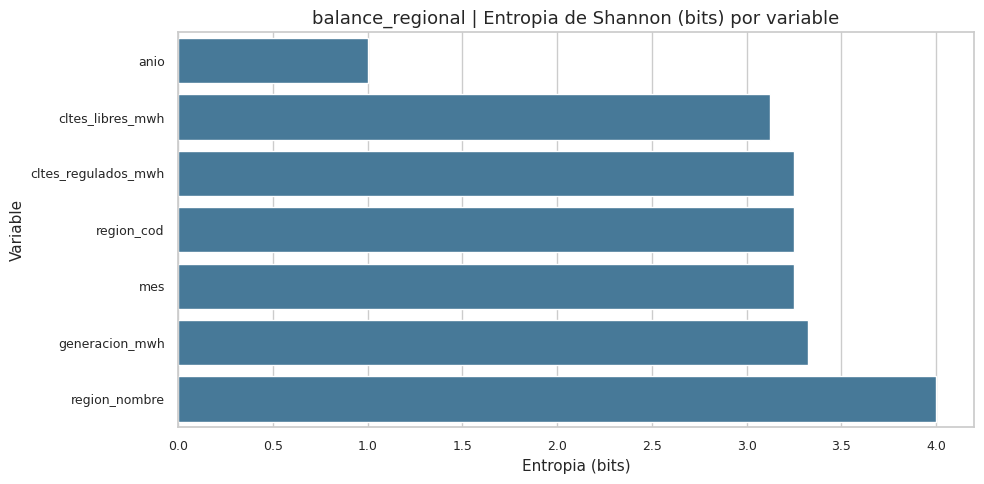


[2] Auditoria de nulos y patron de missingness


,column,missing_pct,max_missing_assoc_spearman,pattern_inference
0,anio,0.0,0.0,Sin nulos
1,mes,0.0,0.0,Sin nulos
2,region_nombre,0.0,0.0,Sin nulos
3,region_cod,0.0,0.0,Sin nulos
4,generacion_mwh,0.0,0.0,Sin nulos
5,cltes_libres_mwh,0.0,0.0,Sin nulos
6,cltes_regulados_mwh,0.0,0.0,Sin nulos


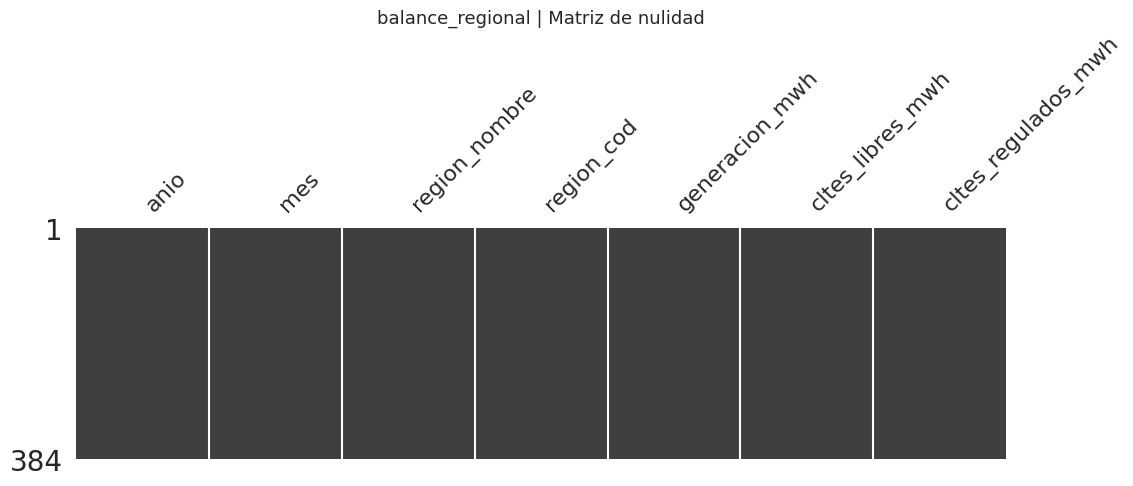

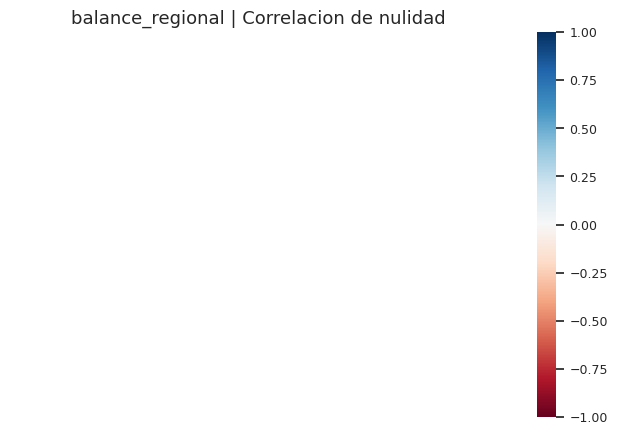


[3] Fuera de rango (OOR)


,column,rule,n_violations,pct_violations,examples
0,mes,(x >= 1) & (x <= 12),0,0.0,
1,anio,(x >= 1990) & (x <= 2035),0,0.0,
2,cltes_libres_mwh,x >= 0,0,0.0,
3,cltes_regulados_mwh,x >= 0,0,0.0,
4,generacion_mwh,x >= 0,0,0.0,



[3] Inconsistencia de formato


,status
0,Sin columnas object para analizar



[3] Ruido / jitter


,column,robust_jitter_rate,median_step,mad_step,noise_flag
4,cltes_libres_mwh,0.2507,-9990.2910,66537.7313,Alta
5,cltes_regulados_mwh,0.1253,9015.7460,74165.5650,Alta
2,region_cod,0.1044,1.0000,1.0000,Alta
3,generacion_mwh,0.0627,26581.3481,261526.3516,Alta
1,mes,0.0601,0.0000,0.0000,Alta
0,anio,0.0026,0.0000,0.0000,Baja



[4] Features concentradas (casi varianza cero)


,column,top1_frequency,near_zero_variance
0,anio,0.5000,False
5,cltes_libres_mwh,0.1875,False
1,mes,0.0833,False
2,region_nombre,0.0625,False
3,region_cod,0.0625,False
6,cltes_regulados_mwh,0.0625,False
4,generacion_mwh,0.0026,False



[4] Outliers unidimensionales (IQR)


,column,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
4,cltes_libres_mwh,18438.035130,244147.952475,225709.917345,-320126.840888,5.827128e+05,48,12.500
3,generacion_mwh,41187.558818,599631.430575,558443.871757,-796478.248819,1.437297e+06,28,7.292
5,cltes_regulados_mwh,39492.099250,147507.977750,108015.878500,-122531.718500,3.095318e+05,24,6.250
0,anio,2019.000000,2020.000000,1.000000,2017.500000,2.021500e+03,0,0.000
1,mes,3.750000,9.250000,5.500000,-4.500000,1.750000e+01,0,0.000
2,region_cod,4.750000,12.250000,7.500000,-6.500000,2.350000e+01,0,0.000


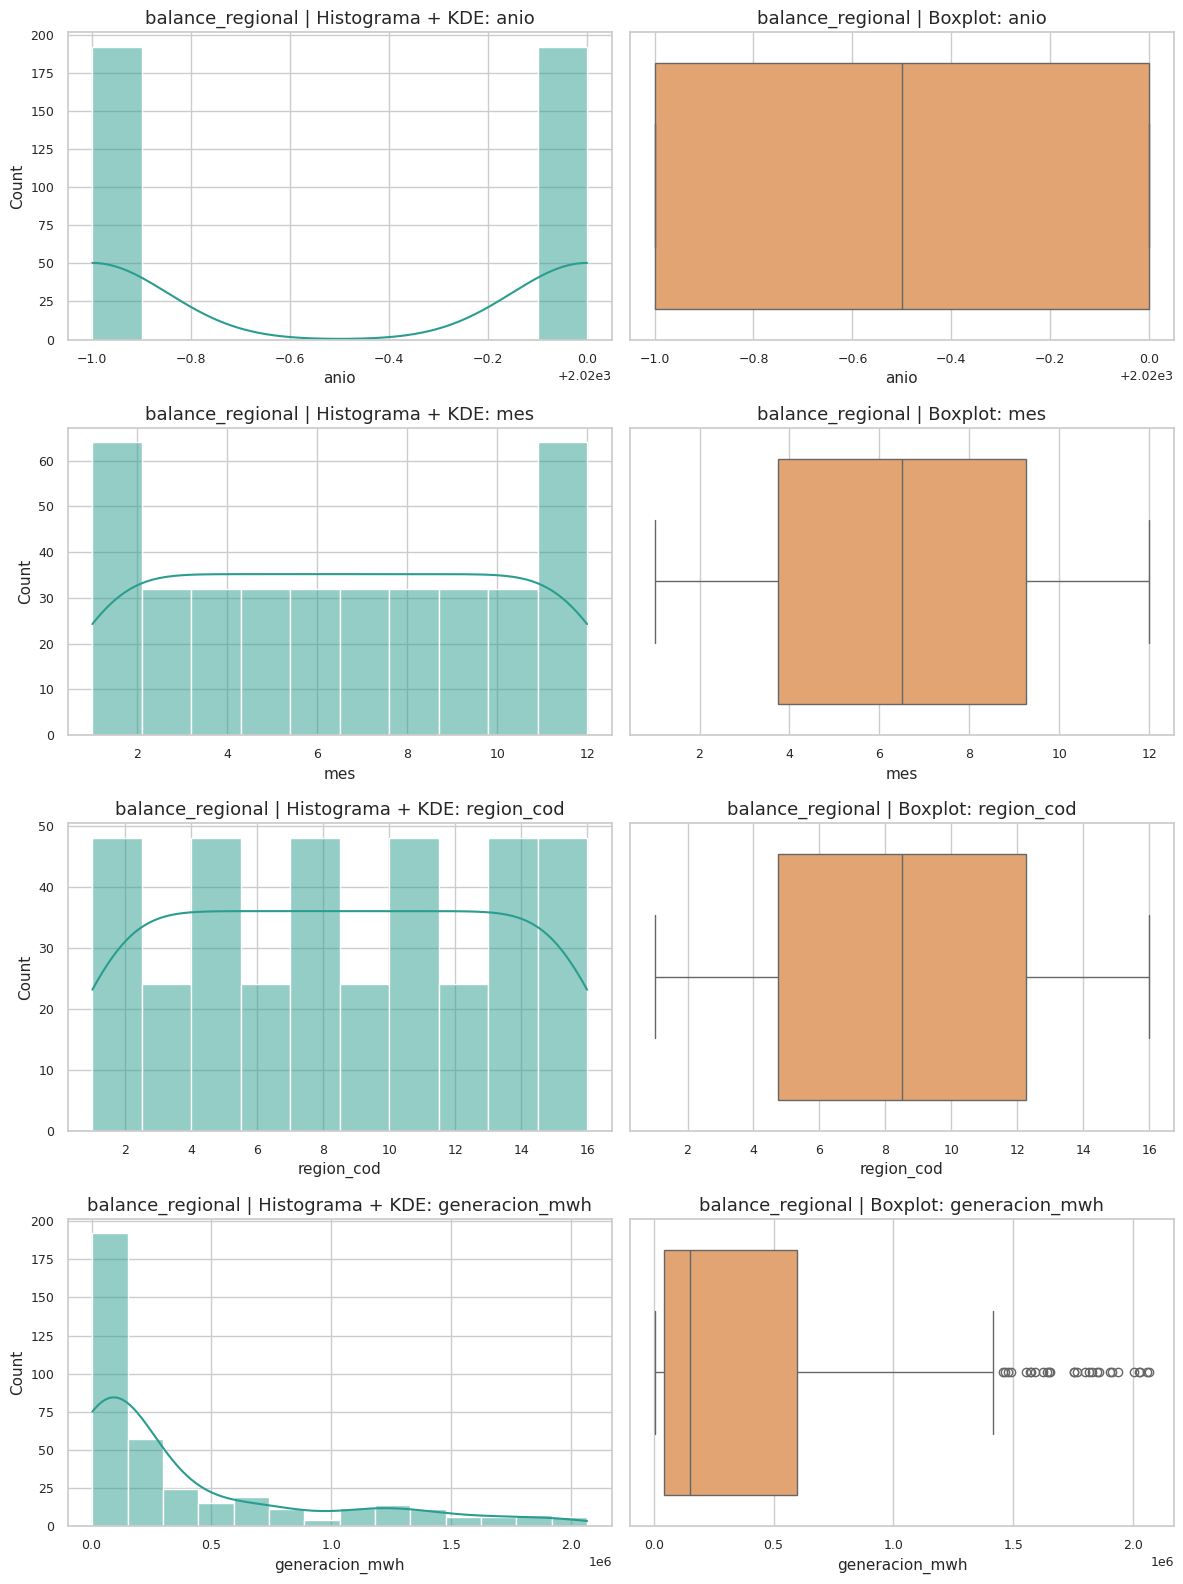

Recomendacion multidimensional: Recomendado analisis multidimensional (Isolation Forest o ECOD): hay multiples variables numericas con outliers relevantes.

[4] Multicolinealidad


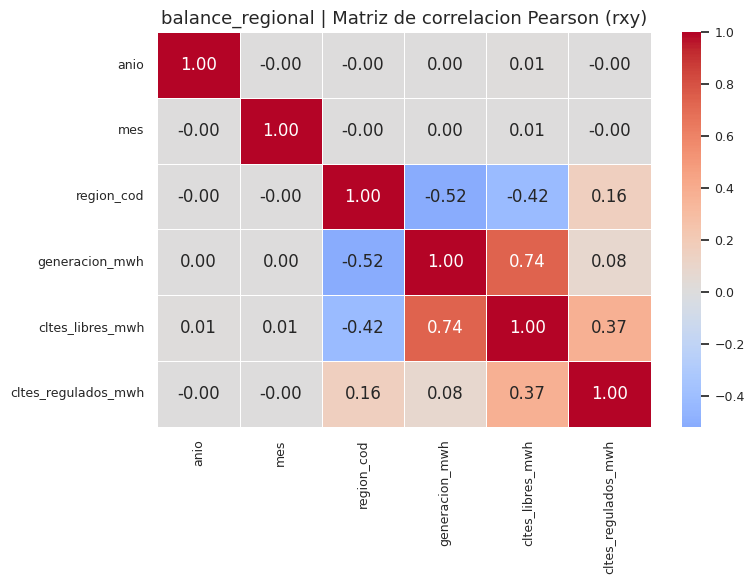

,status
0,Sin pares con |r| >= 0.85



[5] Riesgo de modelado: Information Leakage
Target inferido: generacion_mwh


,target,predictor,risk_level,reason
0,generacion_mwh,anio,Bajo,Sin evidencia fuerte de leakage directo
4,generacion_mwh,cltes_libres_mwh,Bajo,Sin evidencia fuerte de leakage directo
5,generacion_mwh,cltes_regulados_mwh,Bajo,Sin evidencia fuerte de leakage directo
1,generacion_mwh,mes,Bajo,Sin evidencia fuerte de leakage directo
3,generacion_mwh,region_cod,Bajo,Sin evidencia fuerte de leakage directo
2,generacion_mwh,region_nombre,Bajo,Sin evidencia fuerte de leakage directo



DATASET: demanda_diaria | Shape: (11711, 4)


,fecha,sistema,dmin_mw,dmax_mw
0,2006-01-01,SIC,2644.20,4221.86
1,2006-01-01,SING,1379.91,1547.89
2,2006-01-02,SIC,3078.20,5233.15



[1] Tipado semantico por columna


,dataset,column,dtype,semantic_family,semantic_subtype,n_unique,pct_missing,pct_unique,sample_values,min,max
0,demanda_diaria,fecha,datetime64[us],categorical,nominal,7364,0.0,62.881,"2006-01-01, 2006-01-01, 2006-01-02",NaN,NaN
1,demanda_diaria,sistema,str,categorical,nominal,3,0.0,0.026,"SIC, SING, SIC",NaN,NaN
2,demanda_diaria,dmin_mw,float64,numerical,continuous,11542,0.0,98.557,"2644.2, 1379.91, 3078.2",0.12,9700.18
3,demanda_diaria,dmax_mw,float64,numerical,continuous,11536,0.0,98.506,"4221.86, 1547.89, 5233.15",319.81,13213.84



[1] Entropia de Shannon (variables clave)


,dataset,column,semantic_family,semantic_subtype,shannon_entropy_bits
0,demanda_diaria,fecha,categorical,nominal,12.773198
2,demanda_diaria,dmin_mw,numerical,continuous,3.321928
3,demanda_diaria,dmax_mw,numerical,continuous,3.321928
1,demanda_diaria,sistema,categorical,nominal,1.563850


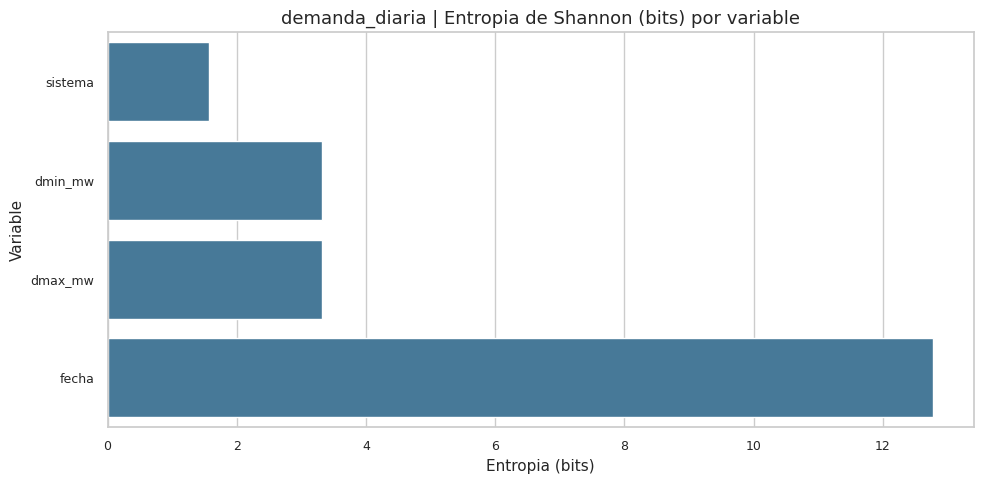


[2] Auditoria de nulos y patron de missingness


,column,missing_pct,max_missing_assoc_spearman,pattern_inference
0,fecha,0.0,0.0,Sin nulos
1,sistema,0.0,0.0,Sin nulos
2,dmin_mw,0.0,0.0,Sin nulos
3,dmax_mw,0.0,0.0,Sin nulos


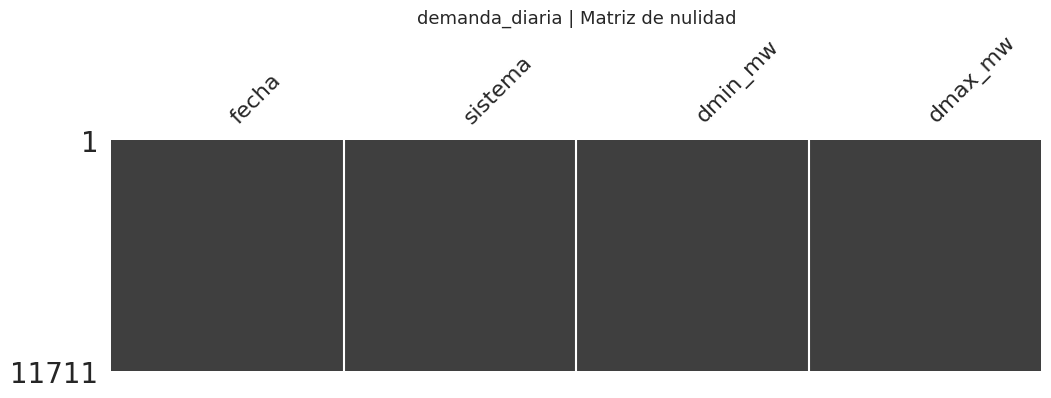

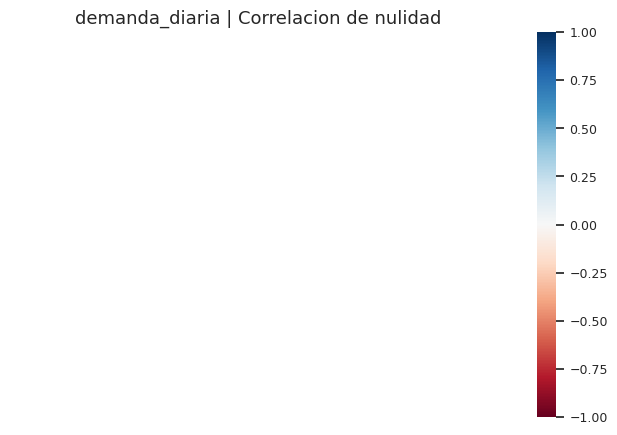


[3] Fuera de rango (OOR)


,column,rule,n_violations,pct_violations,examples
0,fecha,x.notna(),0,0.0,
1,dmax_mw,x >= 0,0,0.0,
2,dmin_mw,x >= 0,0,0.0,



[3] Inconsistencia de formato


,status
0,Sin columnas object para analizar



[3] Ruido / jitter


,column,robust_jitter_rate,median_step,mad_step,noise_flag
0,dmin_mw,0.0,13.230,2286.755,Baja
1,dmax_mw,0.0,-13.815,3761.180,Baja



[4] Features concentradas (casi varianza cero)


,column,top1_frequency,near_zero_variance
1,sistema,0.3743,False
2,dmin_mw,0.0003,False
3,dmax_mw,0.0003,False
0,fecha,0.0002,False



[4] Outliers unidimensionales (IQR)


,column,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
0,dmin_mw,1878.765,6986.410,5107.645,-5782.7025,14647.8775,0,0.0
1,dmax_mw,2078.675,8873.965,6795.290,-8114.2600,19066.9000,0,0.0


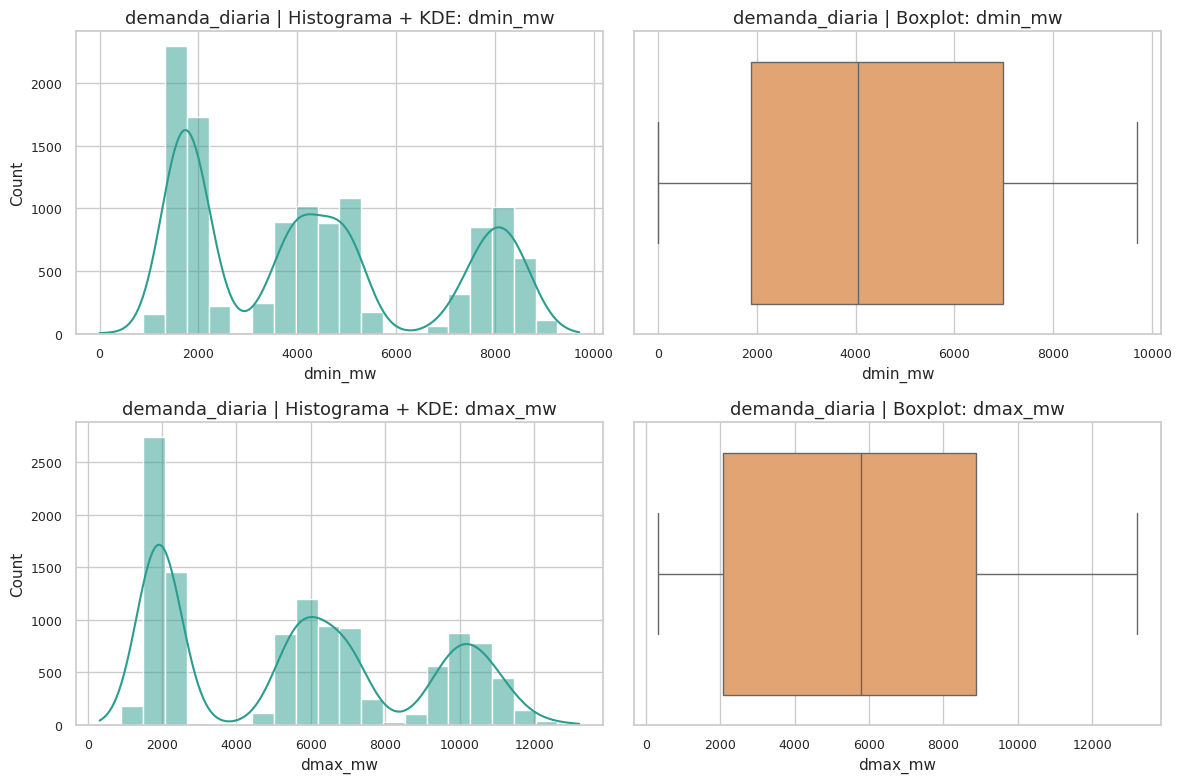

Recomendacion multidimensional: Analisis unidimensional (IQR/boxplot) suficiente en esta etapa diagnostica.

[4] Multicolinealidad


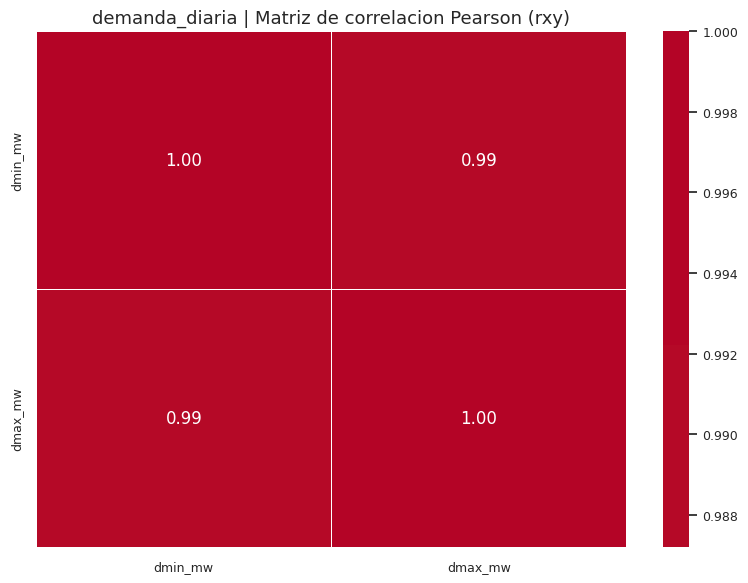

,var_a,var_b,pearson_r,abs_r
0,dmin_mw,dmax_mw,0.9872,0.9872



[5] Riesgo de modelado: Information Leakage
Target inferido: dmax_mw


,target,predictor,risk_level,reason
2,dmax_mw,dmin_mw,Alto,Correlacion extrema con target (r=0.987)
0,dmax_mw,fecha,Bajo,Sin evidencia fuerte de leakage directo
1,dmax_mw,sistema,Bajo,Sin evidencia fuerte de leakage directo



DATASET: demanda_max_capacidad | Shape: (24, 5)


,anio,sistema,cap_instalada_mw,demanda_max_mw,demanda_capacidad
0,2009.0,SIC,11.404,6.139,0.54
1,2009.0,SING,3.699,1.816,0.49
2,2010.0,SIC,12.147,6.482,0.53



[1] Tipado semantico por columna


,dataset,column,dtype,semantic_family,semantic_subtype,n_unique,pct_missing,pct_unique,sample_values,min,max
0,demanda_max_capacidad,anio,float64,numerical,discrete,15,4.167,65.217,"2009.0, 2009.0, 2010.0",2009.000,2023.000
1,demanda_max_capacidad,sistema,str,categorical,nominal,3,4.167,13.043,"SIC, SING, SIC",NaN,NaN
2,demanda_max_capacidad,cap_instalada_mw,float64,numerical,continuous,23,4.167,100.000,"11.404, 3.699, 12.147",3.699,34.276
3,demanda_max_capacidad,demanda_max_mw,float64,numerical,continuous,23,4.167,100.000,"6.139, 1.816, 6.482",1.816,11.917
4,demanda_max_capacidad,demanda_capacidad,float64,numerical,continuous,15,4.167,65.217,"0.54, 0.49, 0.53",0.340,0.550



[1] Entropia de Shannon (variables clave)


,dataset,column,semantic_family,semantic_subtype,shannon_entropy_bits
2,demanda_max_capacidad,cap_instalada_mw,numerical,continuous,3.294664
3,demanda_max_capacidad,demanda_max_mw,numerical,continuous,3.294664
0,demanda_max_capacidad,anio,numerical,discrete,3.273349
4,demanda_max_capacidad,demanda_capacidad,numerical,continuous,3.066615
1,demanda_max_capacidad,sistema,categorical,nominal,1.582193


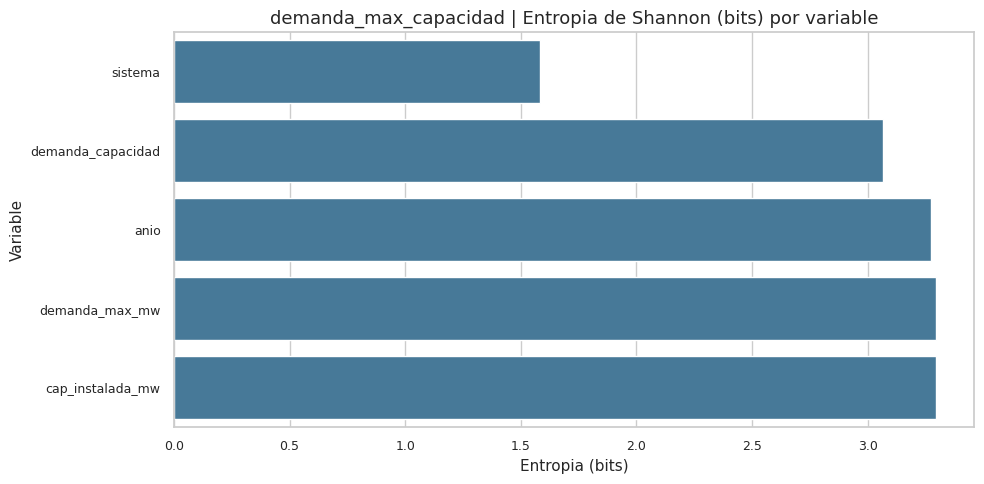


[2] Auditoria de nulos y patron de missingness


,column,missing_pct,max_missing_assoc_spearman,pattern_inference
0,anio,4.167,0.0,MCAR probable
1,sistema,4.167,0.0,MCAR probable
2,cap_instalada_mw,4.167,0.0,MCAR probable
3,demanda_max_mw,4.167,0.0,MCAR probable
4,demanda_capacidad,4.167,0.0,MCAR probable


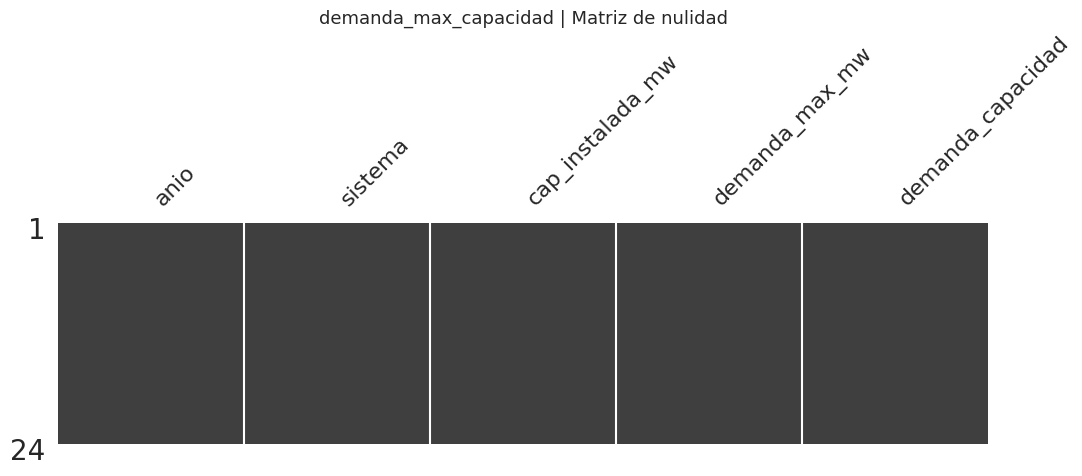

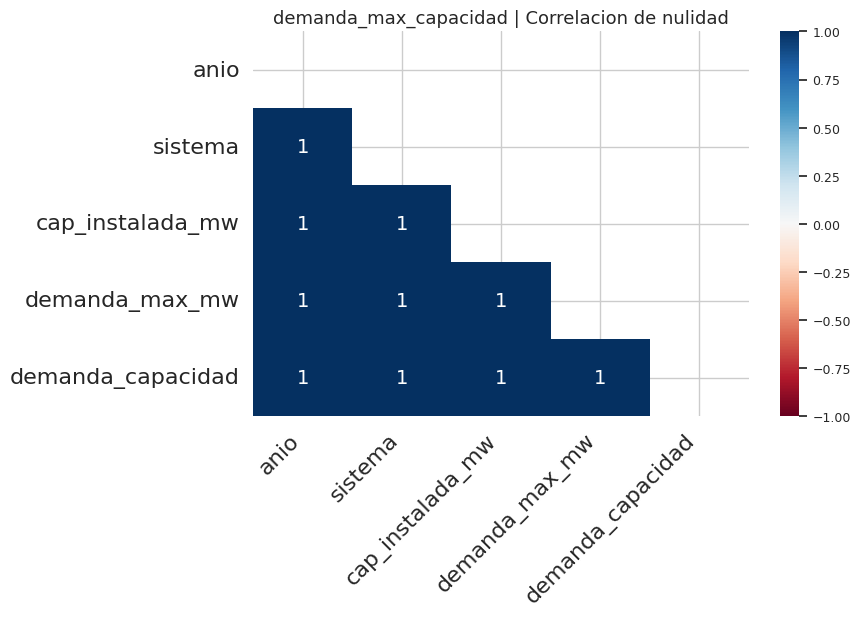


[3] Fuera de rango (OOR)


,column,rule,n_violations,pct_violations,examples
0,anio,(x >= 1990) & (x <= 2035),0,0.0,
1,cap_instalada_mw,x >= 0,0,0.0,
2,demanda_capacidad,x >= 0,0,0.0,
3,demanda_max_mw,x >= 0,0,0.0,
4,demanda_capacidad,(x >= 0) & (x <= 2),0,0.0,



[3] Inconsistencia de formato


,status
0,Sin columnas object para analizar



[3] Ruido / jitter


,column,robust_jitter_rate,median_step,mad_step,noise_flag
0,anio,0.3636,1.000,0.0000,Alta
1,cap_instalada_mw,0.0000,1.078,8.9955,Baja
2,demanda_max_mw,0.0000,0.215,4.9260,Baja
3,demanda_capacidad,0.0000,-0.015,0.0450,Baja



[4] Features concentradas (casi varianza cero)


,column,top1_frequency,near_zero_variance
1,sistema,0.3478,False
4,demanda_capacidad,0.1304,False
0,anio,0.0870,False
2,cap_instalada_mw,0.0435,False
3,demanda_max_mw,0.0435,False



[4] Outliers unidimensionales (IQR)


,column,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
0,anio,2011.5000,2017.5000,6.0000,2002.50000,2026.50000,0,0.0
1,cap_instalada_mw,4.6055,24.1700,19.5645,-24.74125,53.51675,0,0.0
2,demanda_max_mw,2.2425,10.4945,8.2520,-10.13550,22.87250,0,0.0
3,demanda_capacidad,0.4300,0.5100,0.0800,0.31000,0.63000,0,0.0


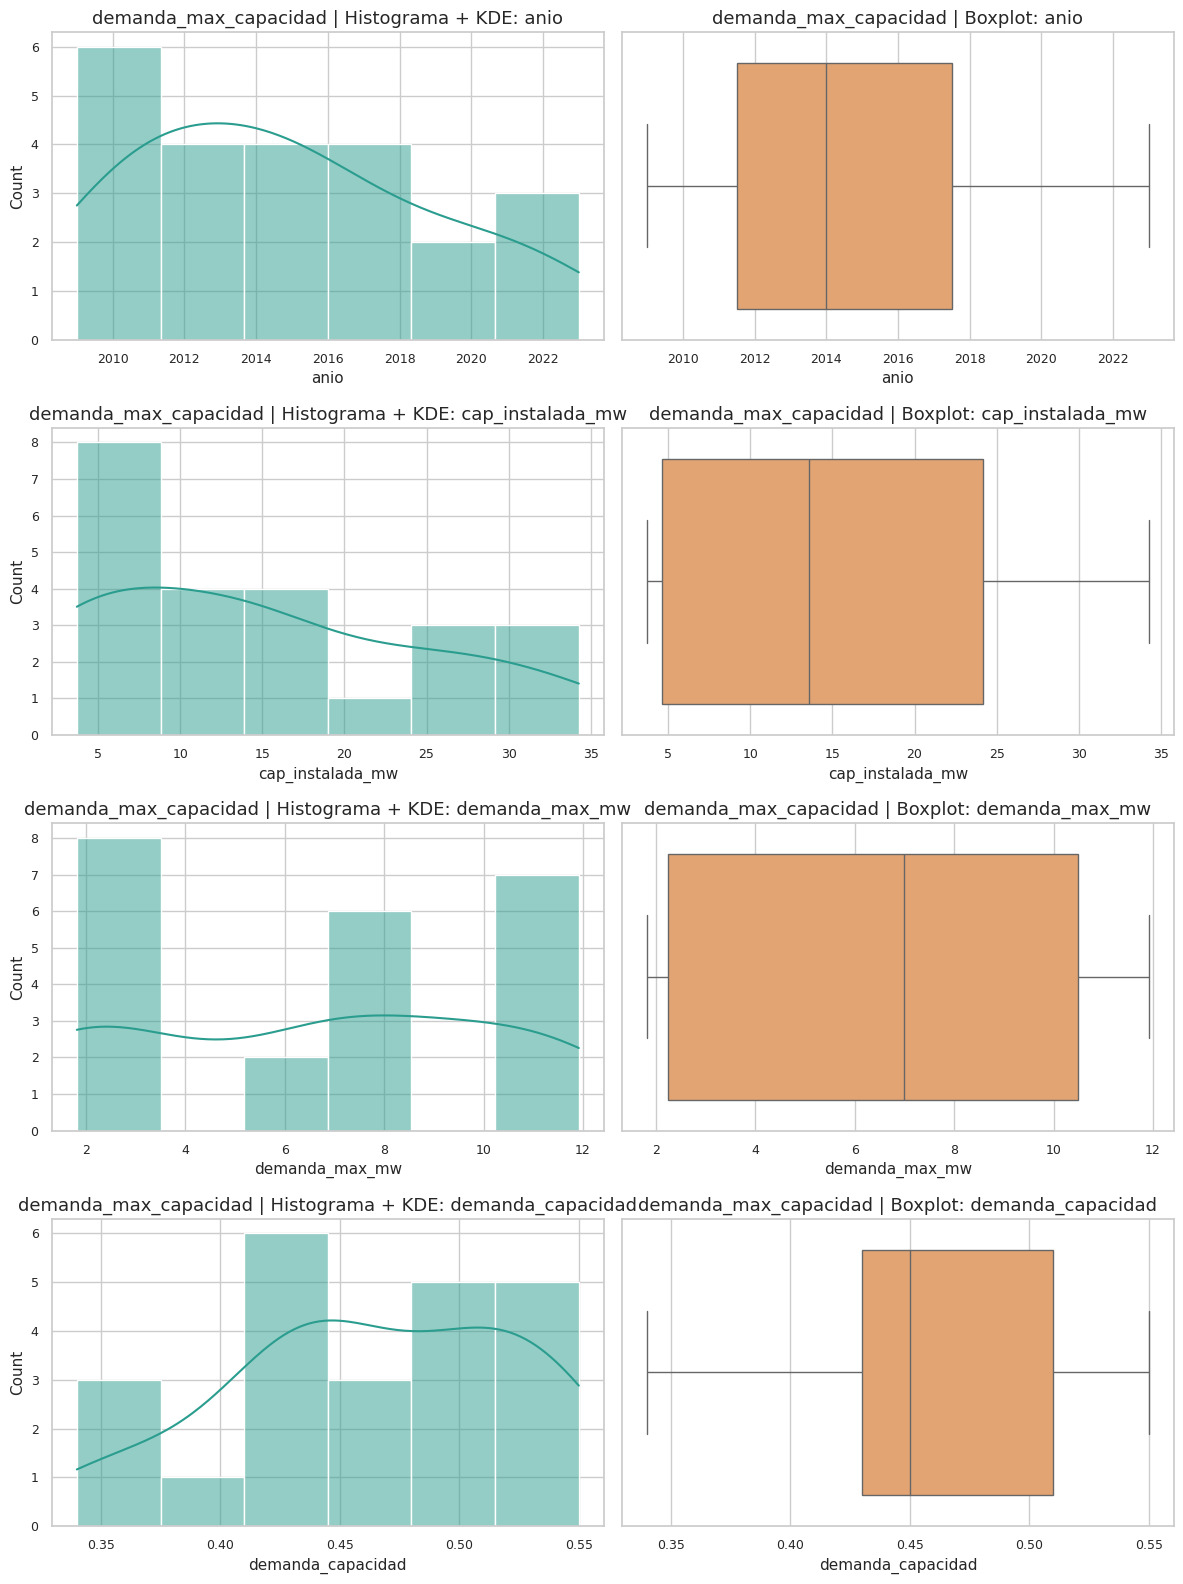

Recomendacion multidimensional: Analisis unidimensional (IQR/boxplot) suficiente en esta etapa diagnostica.

[4] Multicolinealidad


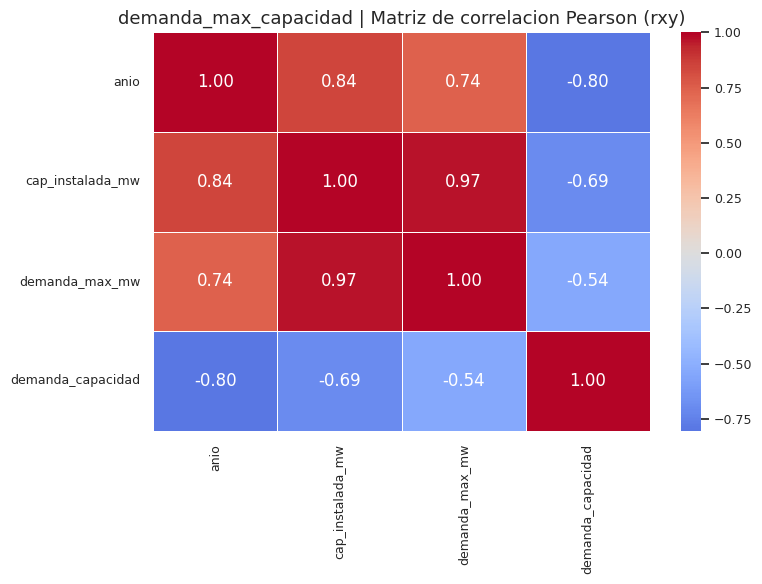

,var_a,var_b,pearson_r,abs_r
0,cap_instalada_mw,demanda_max_mw,0.9713,0.9713



[5] Riesgo de modelado: Information Leakage
Target inferido: demanda_max_mw


,target,predictor,risk_level,reason
2,demanda_max_mw,cap_instalada_mw,Medio,Correlacion muy alta con target (r=0.971)
3,demanda_max_mw,demanda_capacidad,Medio,Posible variable derivada/agregada por nombre
0,demanda_max_mw,anio,Bajo,Sin evidencia fuerte de leakage directo
1,demanda_max_mw,sistema,Bajo,Sin evidencia fuerte de leakage directo



DATASET: dx_programada | Shape: (3718, 2)


,fecha,valor
0,2016-01-12,7354.0
1,2016-01-13,7354.0
2,2016-01-14,7354.0



[1] Tipado semantico por columna


,dataset,column,dtype,semantic_family,semantic_subtype,n_unique,pct_missing,pct_unique,sample_values,min,max
0,dx_programada,fecha,datetime64[us],categorical,nominal,3718,0.0,100.000,"2016-01-12, 2016-01-13, 2016-01-14",NaN,NaN
1,dx_programada,valor,float64,numerical,continuous,3520,0.0,94.675,"7354.0, 7354.0, 7354.0",0.0,13412.305538



[1] Entropia de Shannon (variables clave)


,dataset,column,semantic_family,semantic_subtype,shannon_entropy_bits
0,dx_programada,fecha,categorical,nominal,11.860311
1,dx_programada,valor,numerical,continuous,3.321926


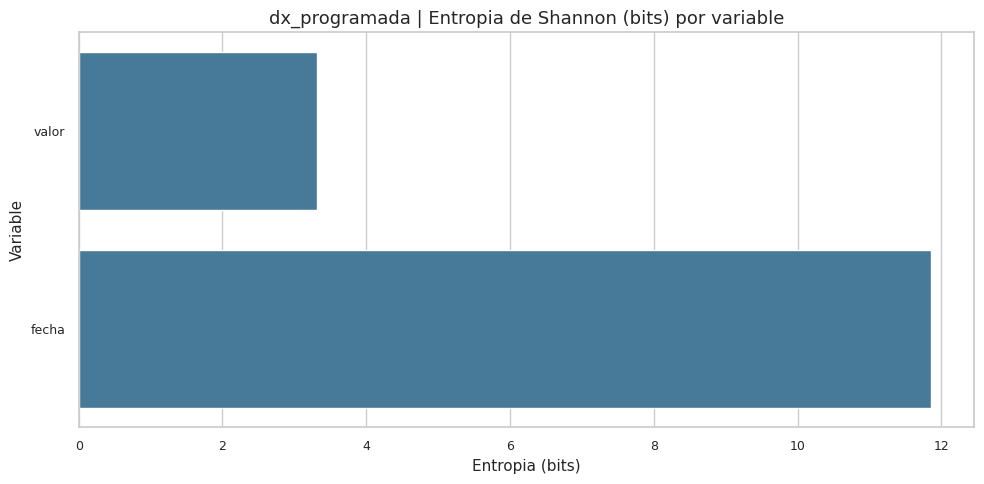


[2] Auditoria de nulos y patron de missingness


,column,missing_pct,max_missing_assoc_spearman,pattern_inference
0,fecha,0.0,0.0,Sin nulos
1,valor,0.0,0.0,Sin nulos


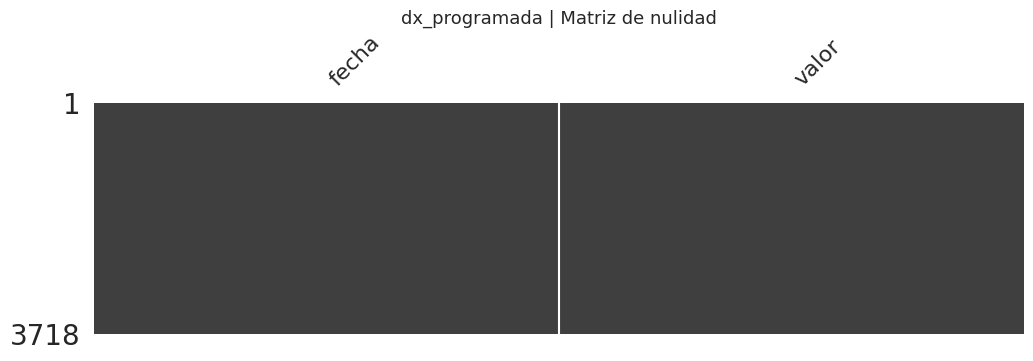

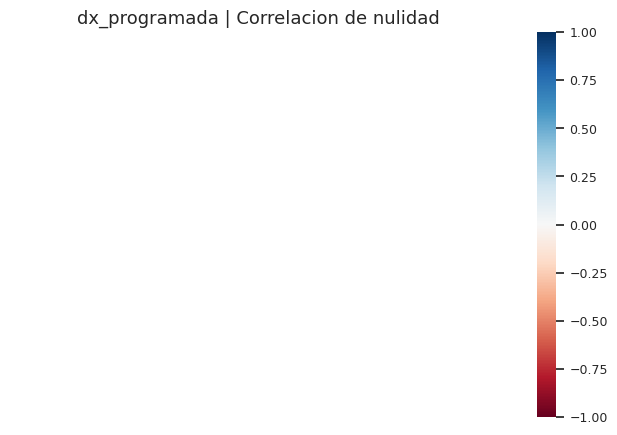


[3] Fuera de rango (OOR)


,column,rule,n_violations,pct_violations,examples
0,fecha,x.notna(),0,0.0,
1,valor,x >= 0,0,0.0,



[3] Inconsistencia de formato


,status
0,Sin columnas object para analizar



[3] Ruido / jitter


,column,robust_jitter_rate,median_step,mad_step,noise_flag
0,valor,0.053,-13.2917,173.5783,Alta



[4] Features concentradas (casi varianza cero)


,column,top1_frequency,near_zero_variance
1,valor,0.0134,False
0,fecha,0.0003,False



[4] Outliers unidimensionales (IQR)


,column,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
0,valor,9319.961788,10628.386467,1308.42468,7357.324768,12591.023487,580,15.6


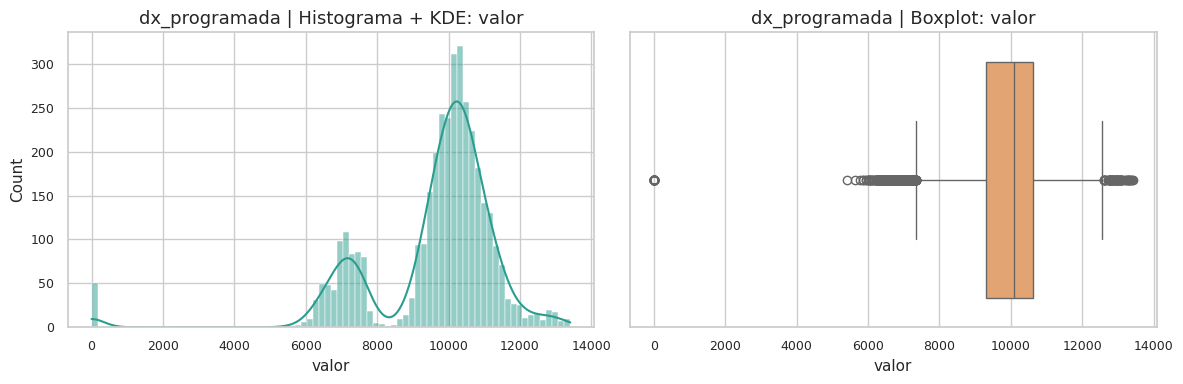

Recomendacion multidimensional: Analisis unidimensional (IQR/boxplot) suficiente en esta etapa diagnostica.

[4] Multicolinealidad


,status
0,Sin pares con |r| >= 0.85



[5] Riesgo de modelado: Information Leakage
Target inferido: valor


,target,predictor,risk_level,reason
0,valor,fecha,Bajo,Sin evidencia fuerte de leakage directo



DATASET: facturacion_regulados | Shape: (490758, 10)


,anio,mes,region,comuna,tipo_clientes,tarifa,clientes_facturados,e1_kwh,e2_kwh,energia_kwh
0,2015,1,Región del Libertador Gral. Bernardo O’Higgins,Las Cabras,No Residencial,BT2PP,179.0,108809.0,0.0,108809
1,2015,1,Región del Libertador Gral. Bernardo O’Higgins,Las Cabras,No Residencial,AT4.3,128.0,3241469.0,0.0,3241469
2,2015,1,Región del Libertador Gral. Bernardo O’Higgins,Las Cabras,No Residencial,AT4.2,14.0,257092.0,0.0,257092



[1] Tipado semantico por columna


,dataset,column,dtype,semantic_family,semantic_subtype,n_unique,pct_missing,pct_unique,sample_values,min,max
0,facturacion_regulados,anio,int64,numerical,discrete,10,0.000,0.002,"2015, 2015, 2015",2015.0,2024.0
1,facturacion_regulados,mes,int64,numerical,discrete,12,0.000,0.002,"1, 1, 1",1.0,12.0
2,facturacion_regulados,region,str,categorical,nominal,16,0.000,0.003,Región del Libertador Gral. Bernardo O’Higgins...,NaN,NaN
3,facturacion_regulados,comuna,str,categorical,nominal,330,0.000,0.067,"Las Cabras, Las Cabras, Las Cabras",NaN,NaN
4,facturacion_regulados,tipo_clientes,str,categorical,nominal,2,0.000,0.000,"No Residencial, No Residencial, No Residencial",NaN,NaN
5,facturacion_regulados,tarifa,str,categorical,nominal,31,0.000,0.006,"BT2PP, AT4.3, AT4.2",NaN,NaN
6,facturacion_regulados,clientes_facturados,float64,numerical,discrete,22697,0.000,4.625,"179.0, 128.0, 14.0",-10.0,476166.0
7,facturacion_regulados,e1_kwh,float64,numerical,continuous,222494,0.279,45.464,"108809.0, 3241469.0, 257092.0",-4812180.0,106130977.0
8,facturacion_regulados,e2_kwh,float64,numerical,discrete,19929,9.726,4.498,"0.0, 0.0, 0.0",-278699.0,12789230.0
9,facturacion_regulados,energia_kwh,int64,numerical,continuous,222537,0.000,45.346,"108809, 3241469, 257092",-4812180.0,112039986.0



[1] Entropia de Shannon (variables clave)


,dataset,column,semantic_family,semantic_subtype,shannon_entropy_bits
3,facturacion_regulados,comuna,categorical,nominal,8.340157
5,facturacion_regulados,tarifa,categorical,nominal,4.019393
2,facturacion_regulados,region,categorical,nominal,3.598448
7,facturacion_regulados,e1_kwh,numerical,continuous,3.321928
9,facturacion_regulados,energia_kwh,numerical,continuous,3.321928
6,facturacion_regulados,clientes_facturados,numerical,discrete,3.298938
1,facturacion_regulados,mes,numerical,discrete,3.250931
0,facturacion_regulados,anio,numerical,discrete,3.129610
4,facturacion_regulados,tipo_clientes,categorical,nominal,0.501614
8,facturacion_regulados,e2_kwh,numerical,discrete,0.307587


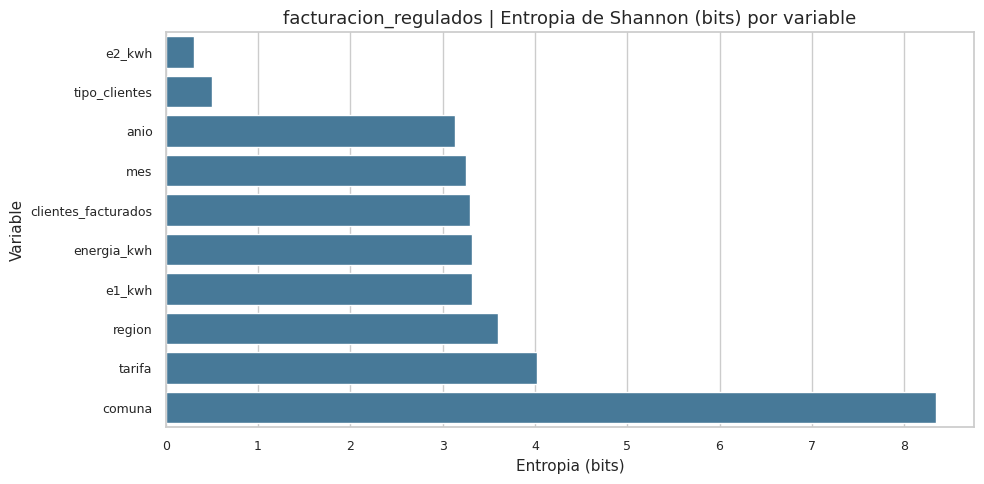


[2] Auditoria de nulos y patron de missingness


,column,missing_pct,max_missing_assoc_spearman,pattern_inference
8,e2_kwh,9.726,0.2740,MAR probable
7,e1_kwh,0.279,0.0887,MCAR probable
1,mes,0.000,0.0000,Sin nulos
0,anio,0.000,0.0000,Sin nulos
2,region,0.000,0.0000,Sin nulos
3,comuna,0.000,0.0000,Sin nulos
5,tarifa,0.000,0.0000,Sin nulos
4,tipo_clientes,0.000,0.0000,Sin nulos
6,clientes_facturados,0.000,0.0019,MCAR probable
9,energia_kwh,0.000,0.0000,Sin nulos


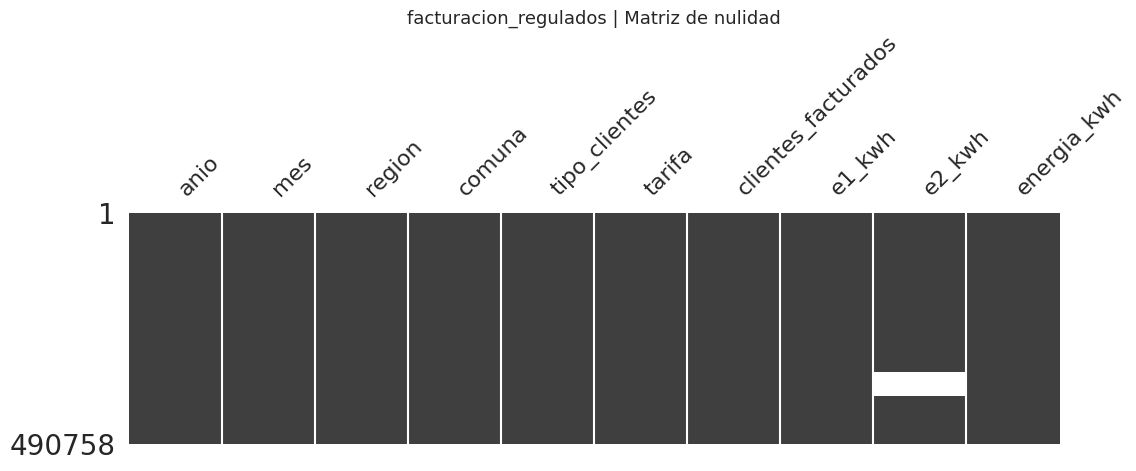

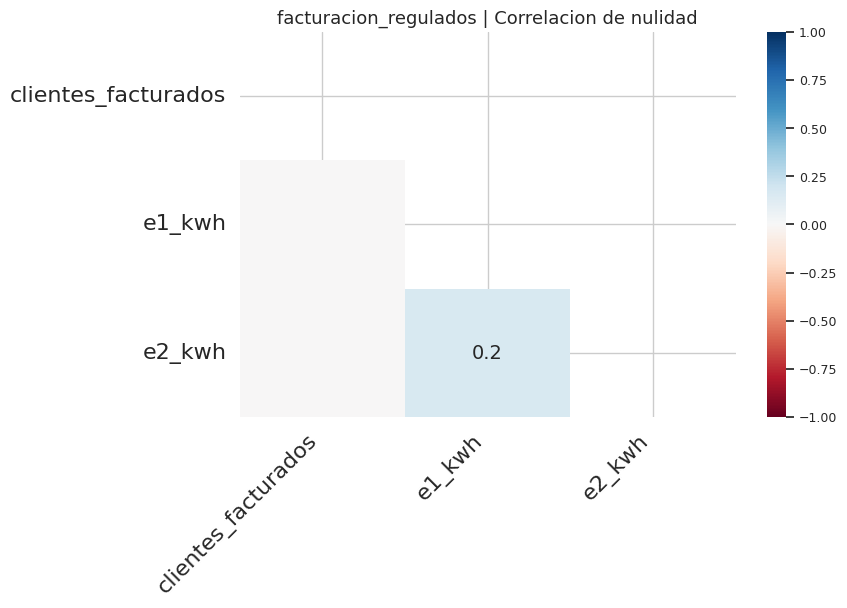


[3] Fuera de rango (OOR)


,column,rule,n_violations,pct_violations,examples
4,e2_kwh,x >= 0,2966,0.604,"-153.0, -732.0, -47.0, -289.0, -307.0"
5,energia_kwh,x >= 0,1191,0.243,"-713, -1470, -3, -1635, -34522"
3,e1_kwh,x >= 0,1190,0.242,"-713.0, -1470.0, -3.0, -1635.0, -34522.0"
2,clientes_facturados,x >= 0,1,0.000,-10.0
0,mes,(x >= 1) & (x <= 12),0,0.000,
1,anio,(x >= 1990) & (x <= 2035),0,0.000,
6,tipo_clientes,x >= 0,0,0.000,



[3] Inconsistencia de formato


,status
0,Sin columnas object para analizar



[3] Ruido / jitter


,column,robust_jitter_rate,median_step,mad_step,noise_flag
5,energia_kwh,0.2601,0.0,62414.0,Alta
3,e1_kwh,0.2595,0.0,62807.0,Alta
2,clientes_facturados,0.2349,0.0,20.0,Alta
4,e2_kwh,0.1037,0.0,0.0,Alta
1,mes,0.0002,0.0,0.0,Baja
0,anio,0.0000,0.0,0.0,Baja



[4] Features concentradas (casi varianza cero)


,column,top1_frequency,near_zero_variance
8,e2_kwh,0.9382,False
4,tipo_clientes,0.8894,False
2,region,0.1511,False
6,clientes_facturados,0.1106,False
0,anio,0.1048,False
1,mes,0.0836,False
5,tarifa,0.0803,False
9,energia_kwh,0.0271,False
7,e1_kwh,0.0244,False
3,comuna,0.0042,False



[4] Outliers unidimensionales (IQR)


,column,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
5,energia_kwh,6775.0,177957.0,171182.0,-249998.0,434730.0,80913,16.487
3,e1_kwh,6878.0,178830.0,171952.0,-251050.0,436758.0,80567,16.463
2,clientes_facturados,3.0,52.0,49.0,-70.5,125.5,76093,15.505
4,e2_kwh,0.0,0.0,0.0,0.0,0.0,27367,6.177
1,mes,3.0,9.0,6.0,-6.0,18.0,0,0.000
0,anio,2017.0,2022.0,5.0,2009.5,2029.5,0,0.000


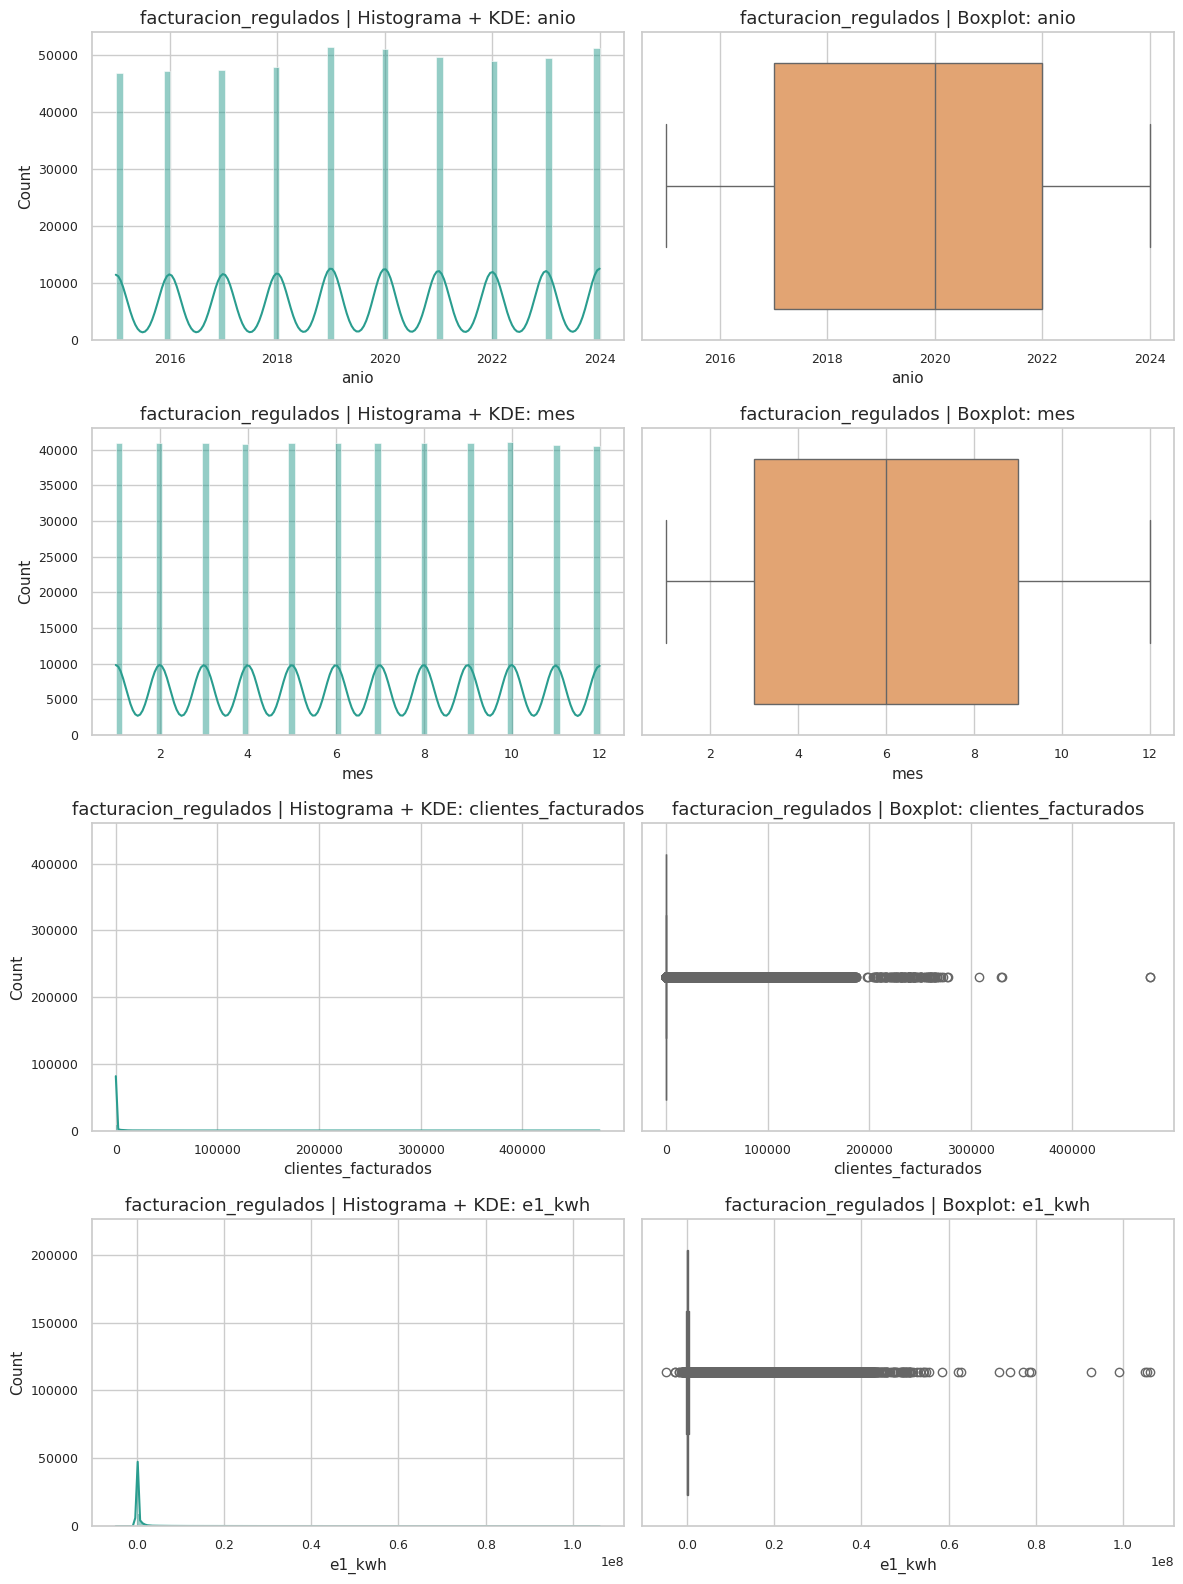

Recomendacion multidimensional: Recomendado analisis multidimensional (Isolation Forest o ECOD): hay multiples variables numericas con outliers relevantes.

[4] Multicolinealidad


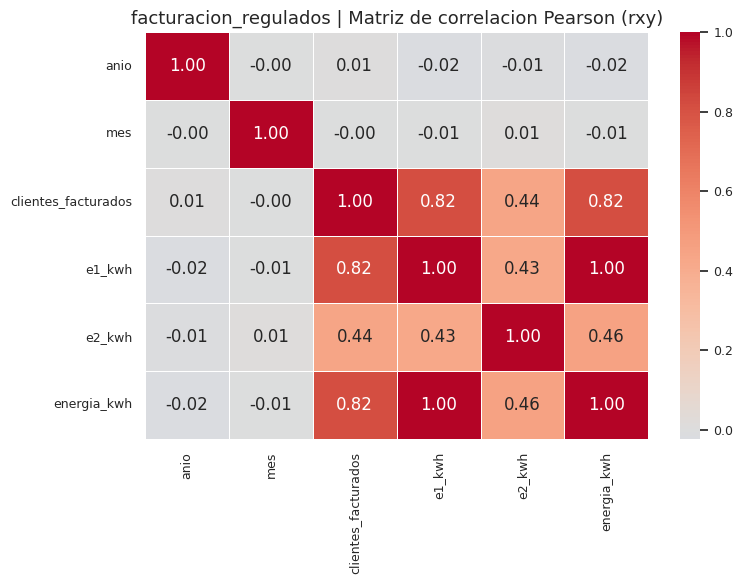

,var_a,var_b,pearson_r,abs_r
0,e1_kwh,energia_kwh,0.9994,0.9994



[5] Riesgo de modelado: Information Leakage
Target inferido: energia_kwh


,target,predictor,risk_level,reason
7,energia_kwh,e1_kwh,Alto,Correlacion extrema con target (r=0.999) | Exi...
8,energia_kwh,e2_kwh,Alto,Existe relacion estructural energia_kwh = e1_k...
0,energia_kwh,anio,Bajo,Existe relacion estructural energia_kwh = e1_k...
6,energia_kwh,clientes_facturados,Bajo,Existe relacion estructural energia_kwh = e1_k...
3,energia_kwh,comuna,Bajo,Existe relacion estructural energia_kwh = e1_k...
1,energia_kwh,mes,Bajo,Existe relacion estructural energia_kwh = e1_k...
2,energia_kwh,region,Bajo,Existe relacion estructural energia_kwh = e1_k...
5,energia_kwh,tarifa,Bajo,Existe relacion estructural energia_kwh = e1_k...
4,energia_kwh,tipo_clientes,Bajo,Existe relacion estructural energia_kwh = e1_k...



DATASET: facturacion_regulados_duplicado | Shape: (490758, 10)


,anio,mes,region,comuna,tipo_clientes,tarifa,clientes_facturados,e1_kwh,e2_kwh,energia_kwh
0,2015,1,Región del Libertador Gral. Bernardo O’Higgins,Las Cabras,No Residencial,BT2PP,179.0,108809.0,0.0,108809
1,2015,1,Región del Libertador Gral. Bernardo O’Higgins,Las Cabras,No Residencial,AT4.3,128.0,3241469.0,0.0,3241469
2,2015,1,Región del Libertador Gral. Bernardo O’Higgins,Las Cabras,No Residencial,AT4.2,14.0,257092.0,0.0,257092



[1] Tipado semantico por columna


,dataset,column,dtype,semantic_family,semantic_subtype,n_unique,pct_missing,pct_unique,sample_values,min,max
0,facturacion_regulados_duplicado,anio,int64,numerical,discrete,10,0.000,0.002,"2015, 2015, 2015",2015.0,2024.0
1,facturacion_regulados_duplicado,mes,int64,numerical,discrete,12,0.000,0.002,"1, 1, 1",1.0,12.0
2,facturacion_regulados_duplicado,region,str,categorical,nominal,16,0.000,0.003,Región del Libertador Gral. Bernardo O’Higgins...,NaN,NaN
3,facturacion_regulados_duplicado,comuna,str,categorical,nominal,330,0.000,0.067,"Las Cabras, Las Cabras, Las Cabras",NaN,NaN
4,facturacion_regulados_duplicado,tipo_clientes,str,categorical,nominal,2,0.000,0.000,"No Residencial, No Residencial, No Residencial",NaN,NaN
5,facturacion_regulados_duplicado,tarifa,str,categorical,nominal,31,0.000,0.006,"BT2PP, AT4.3, AT4.2",NaN,NaN
6,facturacion_regulados_duplicado,clientes_facturados,float64,numerical,discrete,22697,0.000,4.625,"179.0, 128.0, 14.0",-10.0,476166.0
7,facturacion_regulados_duplicado,e1_kwh,float64,numerical,continuous,222494,0.279,45.464,"108809.0, 3241469.0, 257092.0",-4812180.0,106130977.0
8,facturacion_regulados_duplicado,e2_kwh,float64,numerical,discrete,19929,9.726,4.498,"0.0, 0.0, 0.0",-278699.0,12789230.0
9,facturacion_regulados_duplicado,energia_kwh,int64,numerical,continuous,222537,0.000,45.346,"108809, 3241469, 257092",-4812180.0,112039986.0



[1] Entropia de Shannon (variables clave)


,dataset,column,semantic_family,semantic_subtype,shannon_entropy_bits
3,facturacion_regulados_duplicado,comuna,categorical,nominal,8.340157
5,facturacion_regulados_duplicado,tarifa,categorical,nominal,4.019393
2,facturacion_regulados_duplicado,region,categorical,nominal,3.598448
7,facturacion_regulados_duplicado,e1_kwh,numerical,continuous,3.321928
9,facturacion_regulados_duplicado,energia_kwh,numerical,continuous,3.321928
6,facturacion_regulados_duplicado,clientes_facturados,numerical,discrete,3.298938
1,facturacion_regulados_duplicado,mes,numerical,discrete,3.250931
0,facturacion_regulados_duplicado,anio,numerical,discrete,3.129610
4,facturacion_regulados_duplicado,tipo_clientes,categorical,nominal,0.501614
8,facturacion_regulados_duplicado,e2_kwh,numerical,discrete,0.307587


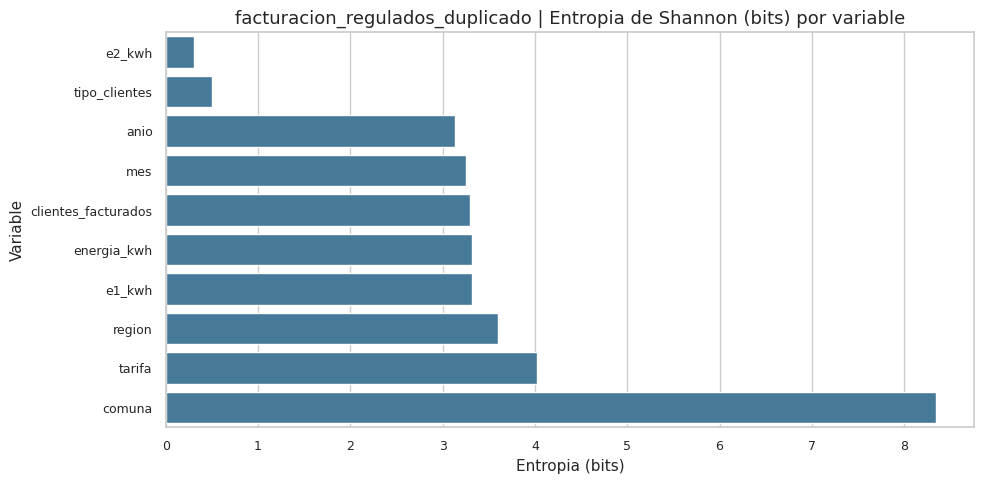


[2] Auditoria de nulos y patron de missingness


,column,missing_pct,max_missing_assoc_spearman,pattern_inference
8,e2_kwh,9.726,0.2740,MAR probable
7,e1_kwh,0.279,0.0887,MCAR probable
1,mes,0.000,0.0000,Sin nulos
0,anio,0.000,0.0000,Sin nulos
2,region,0.000,0.0000,Sin nulos
3,comuna,0.000,0.0000,Sin nulos
5,tarifa,0.000,0.0000,Sin nulos
4,tipo_clientes,0.000,0.0000,Sin nulos
6,clientes_facturados,0.000,0.0019,MCAR probable
9,energia_kwh,0.000,0.0000,Sin nulos


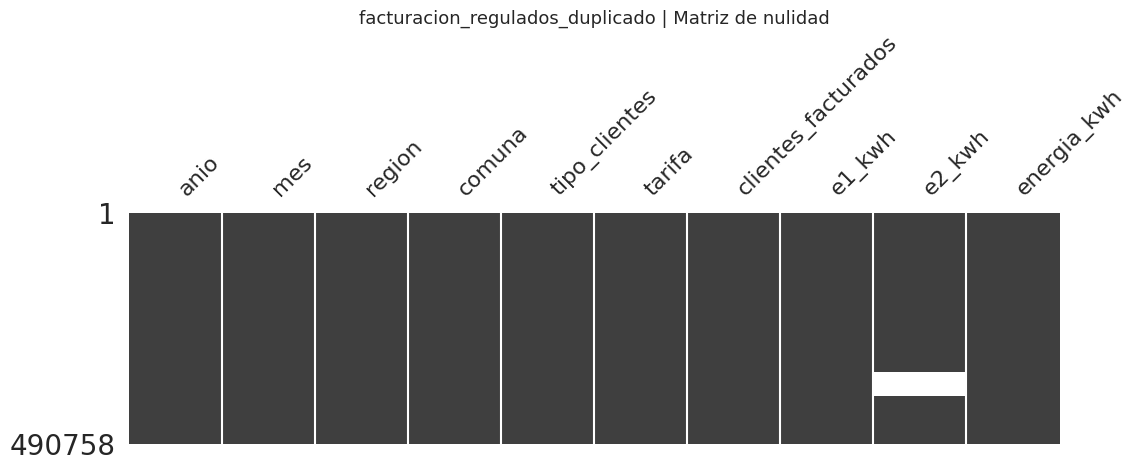

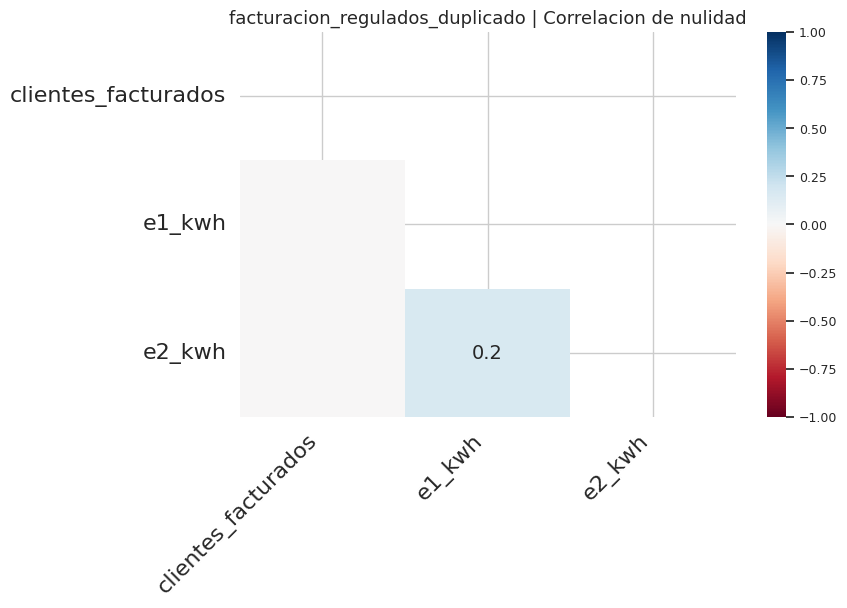


[3] Fuera de rango (OOR)


,column,rule,n_violations,pct_violations,examples
4,e2_kwh,x >= 0,2966,0.604,"-153.0, -732.0, -47.0, -289.0, -307.0"
5,energia_kwh,x >= 0,1191,0.243,"-713, -1470, -3, -1635, -34522"
3,e1_kwh,x >= 0,1190,0.242,"-713.0, -1470.0, -3.0, -1635.0, -34522.0"
2,clientes_facturados,x >= 0,1,0.000,-10.0
0,mes,(x >= 1) & (x <= 12),0,0.000,
1,anio,(x >= 1990) & (x <= 2035),0,0.000,
6,tipo_clientes,x >= 0,0,0.000,



[3] Inconsistencia de formato


,status
0,Sin columnas object para analizar



[3] Ruido / jitter


,column,robust_jitter_rate,median_step,mad_step,noise_flag
5,energia_kwh,0.2601,0.0,62414.0,Alta
3,e1_kwh,0.2595,0.0,62807.0,Alta
2,clientes_facturados,0.2349,0.0,20.0,Alta
4,e2_kwh,0.1037,0.0,0.0,Alta
1,mes,0.0002,0.0,0.0,Baja
0,anio,0.0000,0.0,0.0,Baja



[4] Features concentradas (casi varianza cero)


,column,top1_frequency,near_zero_variance
8,e2_kwh,0.9382,False
4,tipo_clientes,0.8894,False
2,region,0.1511,False
6,clientes_facturados,0.1106,False
0,anio,0.1048,False
1,mes,0.0836,False
5,tarifa,0.0803,False
9,energia_kwh,0.0271,False
7,e1_kwh,0.0244,False
3,comuna,0.0042,False



[4] Outliers unidimensionales (IQR)


,column,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
5,energia_kwh,6775.0,177957.0,171182.0,-249998.0,434730.0,80913,16.487
3,e1_kwh,6878.0,178830.0,171952.0,-251050.0,436758.0,80567,16.463
2,clientes_facturados,3.0,52.0,49.0,-70.5,125.5,76093,15.505
4,e2_kwh,0.0,0.0,0.0,0.0,0.0,27367,6.177
1,mes,3.0,9.0,6.0,-6.0,18.0,0,0.000
0,anio,2017.0,2022.0,5.0,2009.5,2029.5,0,0.000


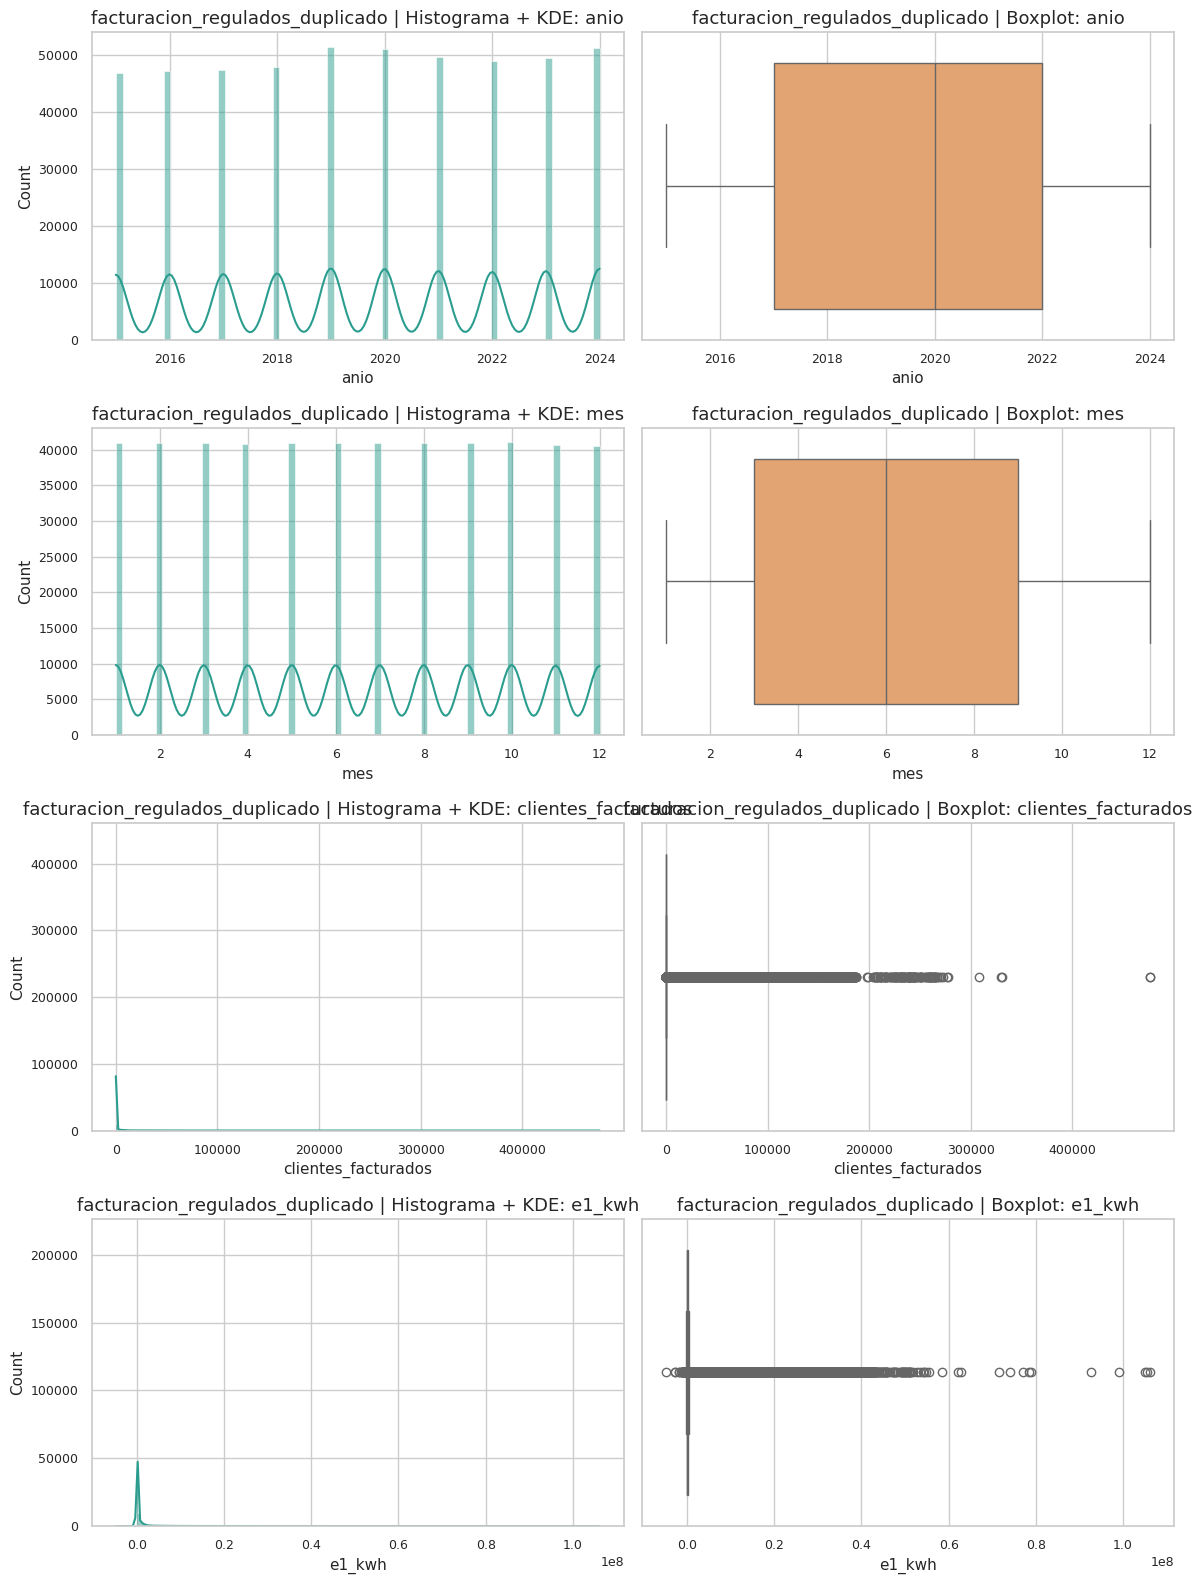

Recomendacion multidimensional: Recomendado analisis multidimensional (Isolation Forest o ECOD): hay multiples variables numericas con outliers relevantes.

[4] Multicolinealidad


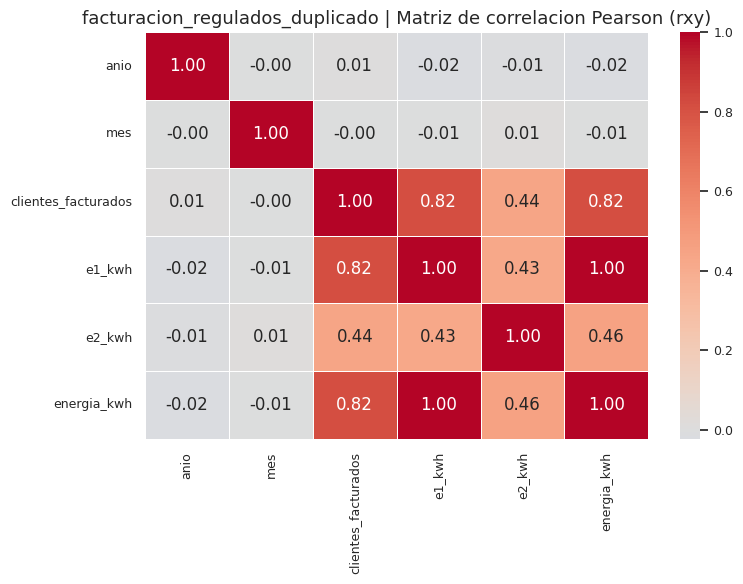

,var_a,var_b,pearson_r,abs_r
0,e1_kwh,energia_kwh,0.9994,0.9994



[5] Riesgo de modelado: Information Leakage
Target inferido: energia_kwh


,target,predictor,risk_level,reason
7,energia_kwh,e1_kwh,Alto,Correlacion extrema con target (r=0.999) | Exi...
8,energia_kwh,e2_kwh,Alto,Existe relacion estructural energia_kwh = e1_k...
0,energia_kwh,anio,Bajo,Existe relacion estructural energia_kwh = e1_k...
6,energia_kwh,clientes_facturados,Bajo,Existe relacion estructural energia_kwh = e1_k...
3,energia_kwh,comuna,Bajo,Existe relacion estructural energia_kwh = e1_k...
1,energia_kwh,mes,Bajo,Existe relacion estructural energia_kwh = e1_k...
2,energia_kwh,region,Bajo,Existe relacion estructural energia_kwh = e1_k...
5,energia_kwh,tarifa,Bajo,Existe relacion estructural energia_kwh = e1_k...
4,energia_kwh,tipo_clientes,Bajo,Existe relacion estructural energia_kwh = e1_k...



DATASET: gx_programada_fuente | Shape: (3718, 5)


,fecha,hidro,termo,ernc,total
0,2016-01-12,74055.0,69960.0,16709.0,160724.0
1,2016-01-13,66608.0,76598.0,15589.0,158795.0
2,2016-01-14,70276.0,71616.0,17317.0,159209.0



[1] Tipado semantico por columna


,dataset,column,dtype,semantic_family,semantic_subtype,n_unique,pct_missing,pct_unique,sample_values,min,max
0,gx_programada_fuente,fecha,datetime64[us],categorical,nominal,3718,0.0,100.000,"2016-01-12, 2016-01-13, 2016-01-14",NaN,NaN
1,gx_programada_fuente,hidro,float64,numerical,continuous,3699,0.0,99.489,"74055.0, 66608.0, 70276.0",0.0,102998.933496
2,gx_programada_fuente,termo,float64,numerical,continuous,3701,0.0,99.543,"69960.0, 76598.0, 71616.0",0.0,164211.264900
3,gx_programada_fuente,ernc,float64,numerical,continuous,3701,0.0,99.543,"16709.0, 15589.0, 17317.0",0.0,151132.827217
4,gx_programada_fuente,total,float64,numerical,continuous,3698,0.0,99.462,"160724.0, 158795.0, 159209.0",0.0,262231.551650



[1] Entropia de Shannon (variables clave)


,dataset,column,semantic_family,semantic_subtype,shannon_entropy_bits
0,gx_programada_fuente,fecha,categorical,nominal,11.860311
1,gx_programada_fuente,hidro,numerical,continuous,3.321927
2,gx_programada_fuente,termo,numerical,continuous,3.321927
3,gx_programada_fuente,ernc,numerical,continuous,3.321927
4,gx_programada_fuente,total,numerical,continuous,3.321927


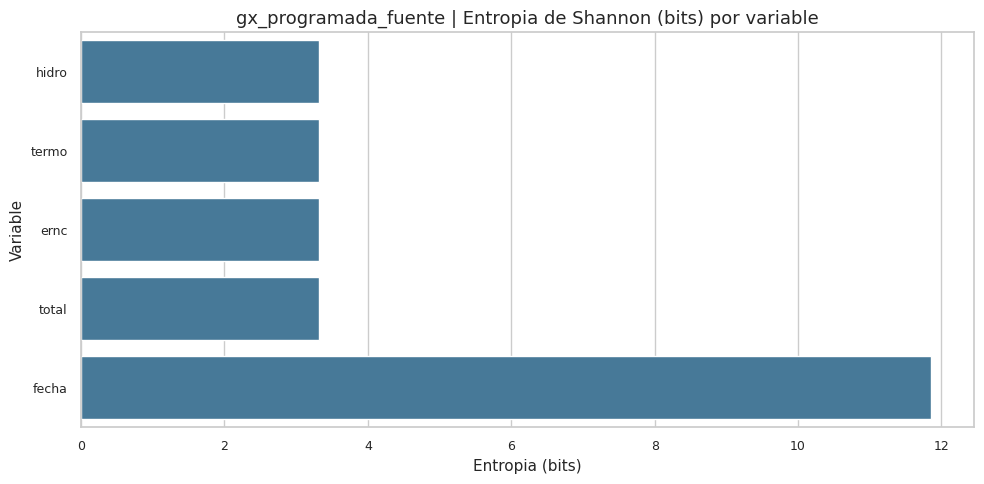


[2] Auditoria de nulos y patron de missingness


,column,missing_pct,max_missing_assoc_spearman,pattern_inference
0,fecha,0.0,0.0,Sin nulos
1,hidro,0.0,0.0,Sin nulos
2,termo,0.0,0.0,Sin nulos
3,ernc,0.0,0.0,Sin nulos
4,total,0.0,0.0,Sin nulos


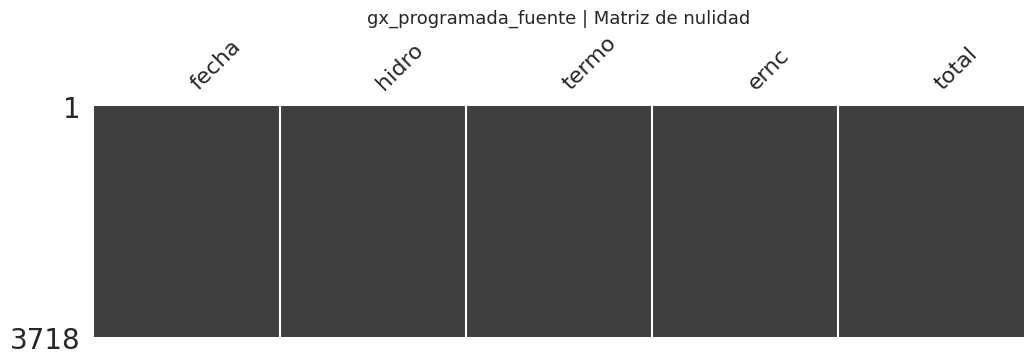

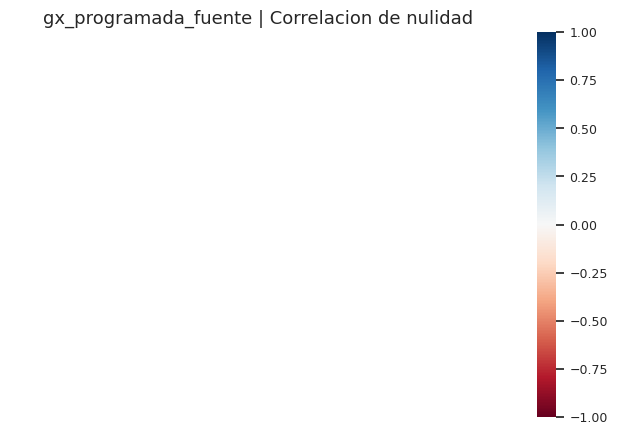


[3] Fuera de rango (OOR)


,column,rule,n_violations,pct_violations,examples
0,fecha,x.notna(),0,0.0,
1,ernc,x >= 0,0,0.0,
2,hidro,x >= 0,0,0.0,
3,termo,x >= 0,0,0.0,
4,total,x >= 0,0,0.0,



[3] Inconsistencia de formato


,status
0,Sin columnas object para analizar



[3] Ruido / jitter


,column,robust_jitter_rate,median_step,mad_step,noise_flag
2,ernc,0.0148,0.0000,3452.1600,Baja
3,total,0.0113,-338.0000,5154.0174,Baja
0,hidro,0.0097,-216.3997,3397.0880,Baja
1,termo,0.0070,-226.4033,5016.6726,Baja



[4] Features concentradas (casi varianza cero)


,column,top1_frequency,near_zero_variance
1,hidro,0.0048,False
3,ernc,0.0048,False
2,termo,0.0048,False
4,total,0.0048,False
0,fecha,0.0003,False



[4] Outliers unidimensionales (IQR)


,column,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
3,total,193932.181000,230376.154123,36443.973123,139266.221315,285042.113808,158,4.250
0,hidro,40590.474635,62946.371657,22355.897023,7056.629101,96480.217191,38,1.022
1,termo,72278.770465,119587.221275,47308.450810,1316.094250,190549.897490,18,0.484
2,ernc,29003.632882,87849.397740,58845.764857,-59265.014403,176118.045026,0,0.000


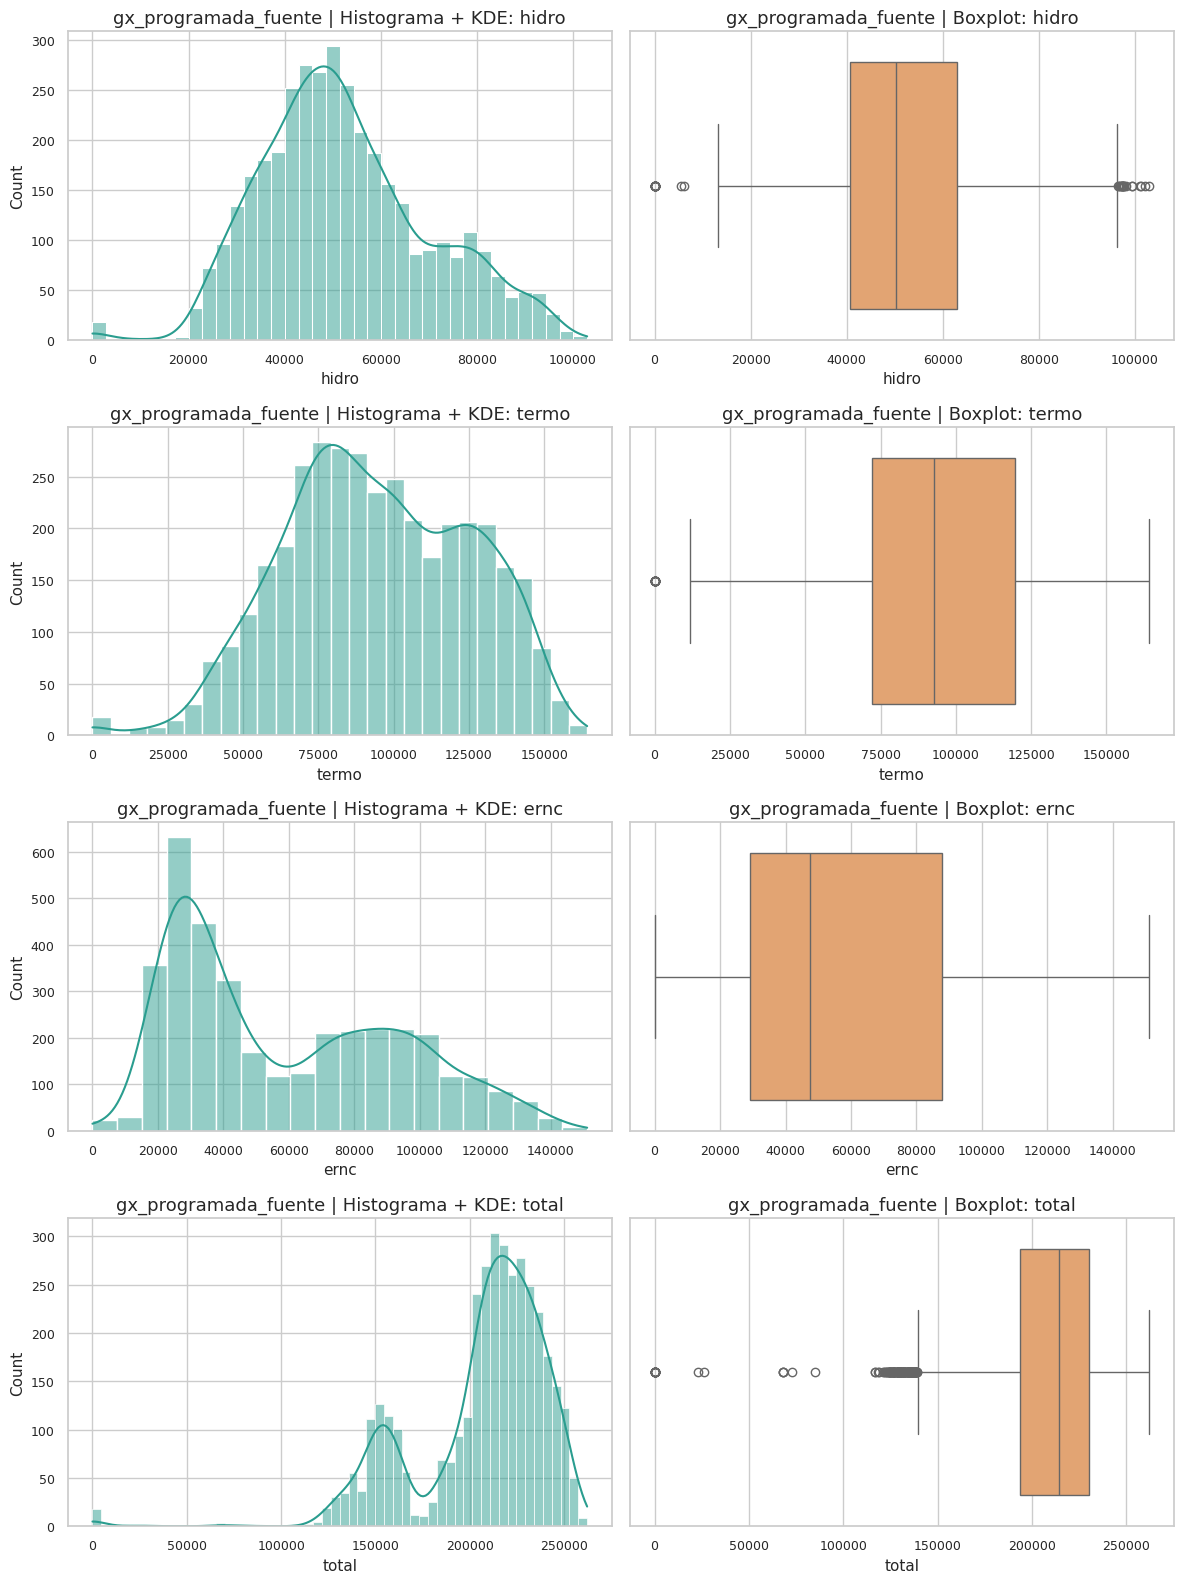

Recomendacion multidimensional: Analisis unidimensional (IQR/boxplot) suficiente en esta etapa diagnostica.

[4] Multicolinealidad


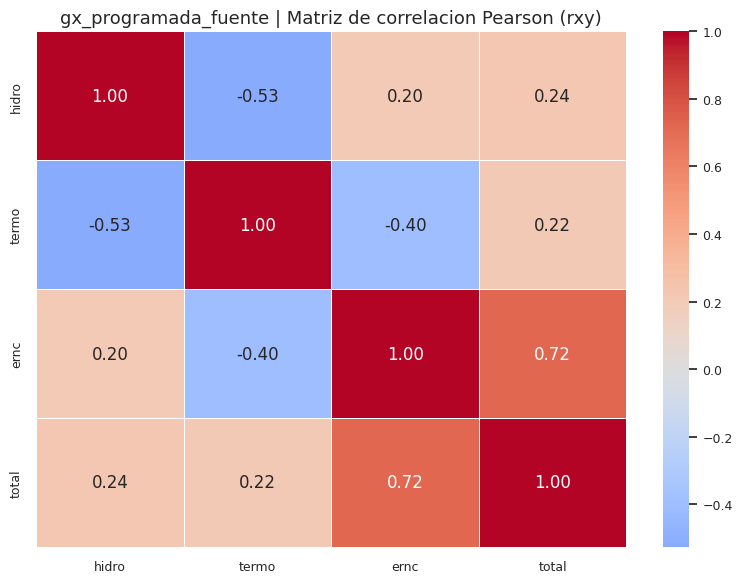

,status
0,Sin pares con |r| >= 0.85



[5] Riesgo de modelado: Information Leakage
Target inferido: total


,target,predictor,risk_level,reason
3,total,ernc,Bajo,Sin evidencia fuerte de leakage directo
0,total,fecha,Bajo,Sin evidencia fuerte de leakage directo
1,total,hidro,Bajo,Sin evidencia fuerte de leakage directo
2,total,termo,Bajo,Sin evidencia fuerte de leakage directo



RESUMEN EJECUTIVO MULTI-DATASET


,dataset,rows,cols,target_inferido,missing_total_pct,n_oor_rules,n_high_corr_pairs,n_high_leakage_flags
0,balance_regional,384,7,generacion_mwh,0.000,0,0,0
1,demanda_diaria,11711,4,dmax_mw,0.000,0,1,1
2,demanda_max_capacidad,24,5,demanda_max_mw,4.167,0,1,0
3,dx_programada,3718,2,valor,0.000,0,0,0
4,facturacion_regulados,490758,10,energia_kwh,1.000,4,1,2
5,facturacion_regulados_duplicado,490758,10,energia_kwh,1.000,4,1,2
6,gx_programada_fuente,3718,5,total,0.000,0,0,0


EDA y auditoria completados (diagnostico).


In [7]:
# Orquestador de analisis por dataset

def show_header(title: str):
    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)


def plot_entropy(ent_df: pd.DataFrame, ds_name: str):
    if ent_df.empty:
        return
    plt.figure(figsize=(10, 5))
    order = ent_df.sort_values("shannon_entropy_bits", ascending=True)
    sns.barplot(data=order, x="shannon_entropy_bits", y="column", color="#3A7CA5")
    plt.title(f"{ds_name} | Entropia de Shannon (bits) por variable")
    plt.xlabel("Entropia (bits)")
    plt.ylabel("Variable")
    plt.tight_layout()
    fig = plt.gcf()
    save_figure_artifact(fig, ds_name, "grafico_entropia")
    plt.show()


def plot_numeric_distributions(df: pd.DataFrame, ds_name: str, max_cols: int = 4):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()[:max_cols]
    if not num_cols:
        return

    n = len(num_cols)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(num_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color="#2A9D8F")
        axes[i, 0].set_title(f"{ds_name} | Histograma + KDE: {col}")

        sns.boxplot(x=df[col], ax=axes[i, 1], color="#F4A261")
        axes[i, 1].set_title(f"{ds_name} | Boxplot: {col}")

    plt.tight_layout()
    save_figure_artifact(fig, ds_name, "grafico_distribuciones_y_boxplots")
    plt.show()


def plot_nullity(df: pd.DataFrame, ds_name: str):
    if df.shape[1] < 2:
        return
    msno.matrix(df, figsize=(12, 3), sparkline=False)
    plt.title(f"{ds_name} | Matriz de nulidad")
    fig = plt.gcf()
    save_figure_artifact(fig, ds_name, "grafico_matriz_nulidad")
    plt.show()

    if df.shape[1] >= 2:
        msno.heatmap(df, figsize=(8, 5))
        plt.title(f"{ds_name} | Correlacion de nulidad")
        fig = plt.gcf()
        save_figure_artifact(fig, ds_name, "grafico_correlacion_nulidad")
        plt.show()


def plot_correlation(corr: pd.DataFrame, ds_name: str):
    if corr.empty:
        return
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
    plt.title(f"{ds_name} | Matriz de correlacion Pearson (rxy)")
    plt.tight_layout()
    fig = plt.gcf()
    save_figure_artifact(fig, ds_name, "grafico_correlacion_pearson")
    plt.show()


all_summaries = []

for ds_name, df in DATASETS.items():
    show_header(f"DATASET: {ds_name} | Shape: {df.shape}")
    preview_df = df.head(3)
    display(preview_df)
    save_table_artifact(preview_df, ds_name, "tabla_preview")

    # 1) Tipado + Entropia
    prof = column_profile(df, ds_name)
    ent = entropy_report(df, ds_name, top_k=min(12, df.shape[1]))
    print("\n[1] Tipado semantico por columna")
    display(prof)
    save_table_artifact(prof, ds_name, "tabla_tipado_semantico")

    print("\n[1] Entropia de Shannon (variables clave)")
    display(ent)
    save_table_artifact(ent, ds_name, "tabla_entropia")
    plot_entropy(ent, ds_name)

    # 2) Nulos + patron MCAR/MAR/MNAR
    print("\n[2] Auditoria de nulos y patron de missingness")
    miss_pattern = infer_missingness_pattern(df)
    display(miss_pattern)
    save_table_artifact(miss_pattern, ds_name, "tabla_nulos_patron")
    plot_nullity(df, ds_name)

    # 3) Fuera de rango + formato + ruido
    print("\n[3] Fuera de rango (OOR)")
    oor = detect_oor(df)
    display(oor)
    save_table_artifact(oor, ds_name, "tabla_oor")

    print("\n[3] Inconsistencia de formato")
    fmt_issues = detect_format_inconsistencies(df)
    fmt_display = fmt_issues if not fmt_issues.empty else pd.DataFrame({"status": ["Sin columnas object para analizar"]})
    display(fmt_display)
    save_table_artifact(fmt_display, ds_name, "tabla_formato")

    print("\n[3] Ruido / jitter")
    noise = detect_noise_jitter(df)
    noise_display = noise if not noise.empty else pd.DataFrame({"status": ["Sin evidencia suficiente para evaluar jitter"]})
    display(noise_display)
    save_table_artifact(noise_display, ds_name, "tabla_ruido_jitter")

    # 4) Features concentradas + outliers + correlacion
    print("\n[4] Features concentradas (casi varianza cero)")
    nzv = near_zero_variance_features(df, threshold=0.99)
    display(nzv)
    save_table_artifact(nzv, ds_name, "tabla_features_concentradas")

    print("\n[4] Outliers unidimensionales (IQR)")
    out_iqr = iqr_outlier_report(df)
    outlier_display = out_iqr if not out_iqr.empty else pd.DataFrame({"status": ["No hay columnas numericas suficientes"]})
    display(outlier_display)
    save_table_artifact(outlier_display, ds_name, "tabla_outliers_iqr")
    plot_numeric_distributions(df, ds_name, max_cols=4)

    rec_multidim = suggest_multidim_outlier_check(df, out_iqr)
    print("Recomendacion multidimensional:", rec_multidim)

    print("\n[4] Multicolinealidad")
    corr, high_pairs = correlation_report(df, corr_threshold=0.85)
    plot_correlation(corr, ds_name)
    corr_pairs_display = high_pairs if not high_pairs.empty else pd.DataFrame({"status": ["Sin pares con |r| >= 0.85"]})
    display(corr_pairs_display)
    save_table_artifact(corr_pairs_display, ds_name, "tabla_multicolinealidad")

    # 5) Riesgo de leakage
    print("\n[5] Riesgo de modelado: Information Leakage")
    target = infer_target_column(df, DATASETS_CONFIG[ds_name])
    leak = leakage_risk_report(df, target)
    print("Target inferido:", target)
    leak_display = leak.head(20)
    display(leak_display)
    save_table_artifact(leak_display, ds_name, "tabla_leakage")

    all_summaries.append({
        "dataset": ds_name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "target_inferido": target,
        "missing_total_pct": round(df.isna().mean().mean() * 100, 3),
        "n_oor_rules": 0 if oor.empty else int((oor["n_violations"] > 0).sum()),
        "n_high_corr_pairs": 0 if high_pairs.empty else int(len(high_pairs)),
        "n_high_leakage_flags": int((leak["risk_level"] == "Alto").sum()) if "risk_level" in leak.columns else 0
    })

show_header("RESUMEN EJECUTIVO MULTI-DATASET")
summary_df = pd.DataFrame(all_summaries).sort_values("dataset")
display(summary_df)
save_table_artifact(summary_df, "resumen_global", "tabla_resumen_ejecutivo")
print("EDA y auditoria completados (diagnostico).")